# Storytelling Two Minute Drill:

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load supplementary data first to understand the context
supp_data = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\raw\\supplementary_data.csv')

# Data Engineering:

In [2]:
# Now let's identify 2-minute drill and red-zone situations
# 2-minute drill: last 2 minutes of each half (quarters 2 and 4)
# Red-zone: within 20 yards of the end zone

def parse_game_clock(clock_str):
    """Convert game clock string to seconds"""
    try:
        parts = clock_str.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

supp_data['game_clock_seconds'] = supp_data['game_clock'].apply(parse_game_clock)

# Identify 2-minute drill situations
supp_data['is_two_minute_drill'] = (
    ((supp_data['quarter'] == 2) | (supp_data['quarter'] == 4)) & 
    (supp_data['game_clock_seconds'] <= 120)
)

# Identify red-zone situations (within 20 yards of end zone)
# yardline_number represents distance from the yardline_side's goal
# We need to calculate absolute yardline
def calculate_absolute_yardline(row):
    """Calculate yards to go for touchdown"""
    if pd.isna(row['yardline_number']):
        return None
    # If yardline_side is the possession team, they're going away from their own goal
    # If yardline_side is the defensive team, they're close to scoring
    if row['yardline_side'] == row['possession_team']:
        return 100 - row['yardline_number']
    else:
        return row['yardline_number']

supp_data['yards_to_endzone'] = supp_data.apply(calculate_absolute_yardline, axis=1)
supp_data['is_redzone'] = supp_data['yards_to_endzone'] <= 20

print("2-Minute Drill Situations:", supp_data['is_two_minute_drill'].sum())
print("Red-Zone Situations:", supp_data['is_redzone'].sum())
print("\nOverlap (Both 2-min and Red-zone):", 
      ((supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])).sum())

# Create completion binary variable
supp_data['is_completion'] = (supp_data['pass_result'] == 'C').astype(int)

print("\n=== COMPLETION RATES ===")
print(f"Overall: {supp_data['is_completion'].mean():.3f}")
print(f"2-Minute Drill: {supp_data[supp_data['is_two_minute_drill']]['is_completion'].mean():.3f}")
print(f"Red-Zone: {supp_data[supp_data['is_redzone']]['is_completion'].mean():.3f}")
print(f"Both: {supp_data[(supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])]['is_completion'].mean():.3f}")

# Save this enhanced supplementary data
supp_data.to_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\processed\\supplementary_enhanced.csv', index=False)

2-Minute Drill Situations: 2762
Red-Zone Situations: 2146

Overlap (Both 2-min and Red-zone): 383

=== COMPLETION RATES ===
Overall: 0.692
2-Minute Drill: 0.673
Red-Zone: 0.623
Both: 0.593


In [3]:
# Load all input and output files and merge with supplementary data
# Define the base path
BASE_PATH = Path('C:/Users/jrzem/Downloads/NFL-Big-Data-Bowl-2026-Analytics-Challenge/data/raw')

# Alternative: if the above doesn't work, try without the project folder name
# BASE_PATH = Path('data/raw')

# Load all weeks using pathlib for cross-platform compatibility
all_input_files = sorted(BASE_PATH.glob('input_2023_w*.csv'))
all_output_files = sorted(BASE_PATH.glob('output_2023_w*.csv'))

# Convert Path objects to strings for pandas
all_input_files = [str(f) for f in all_input_files]
all_output_files = [str(f) for f in all_output_files]

print(f"Found {len(all_input_files)} input files")
print(f"Found {len(all_output_files)} output files")

if len(all_input_files) > 0:
    print("\nInput files found:")
    for f in all_input_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_input_files) > 5:
        print(f"  ... and {len(all_input_files) - 5} more")

if len(all_output_files) > 0:
    print("\nOutput files found:")
    for f in all_output_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_output_files) > 5:
        print(f"  ... and {len(all_output_files) - 5} more")

# For feature engineering, we need to extract features from the last frame before pass
# Let's process week 1 as an example first

if len(all_input_files) > 0:
    # Load week 1 input
    print(f"\nLoading {Path(all_input_files[0]).name}...")
    input_w1 = pd.read_csv(all_input_files[0])

    def extract_features_from_tracking(input_df):
        """Extract features from tracking data at the last frame before pass"""
        # Get the last frame for each player in each play
        last_frames = input_df.groupby(['game_id', 'play_id', 'nfl_id']).tail(1)
        
        # Calculate additional features
        features = last_frames.copy()
        
        # Distance to ball landing spot
        features['dist_to_ball_land'] = np.sqrt(
            (features['x'] - features['ball_land_x'])**2 + 
            (features['y'] - features['ball_land_y'])**2
        )
        
        # Speed and acceleration features
        features['speed_x_accel'] = features['s'] * features['a']
        
        return features

    # Process week 1
    week1_features = extract_features_from_tracking(input_w1)

    print("\nExtracted features shape:", week1_features.shape)
    print("\nFeatures for targeted receivers:")
    targeted = week1_features[week1_features['player_role'] == 'Targeted Receiver']
    print(f"Targeted receivers: {len(targeted)}")
    print("\nSample features:")
    print(targeted[['game_id', 'play_id', 'player_name', 'x', 'y', 's', 'a', 
                   'dist_to_ball_land', 'ball_land_x', 'ball_land_y']].head())
    
else:
    print("\n❌ No input files found.")

Found 18 input files
Found 18 output files

Input files found:
  - input_2023_w01.csv
  - input_2023_w02.csv
  - input_2023_w03.csv
  - input_2023_w04.csv
  - input_2023_w05.csv
  ... and 13 more

Output files found:
  - output_2023_w01.csv
  - output_2023_w02.csv
  - output_2023_w03.csv
  - output_2023_w04.csv
  - output_2023_w05.csv
  ... and 13 more

Loading input_2023_w01.csv...



Extracted features shape: (10089, 25)

Features for targeted receivers:
Targeted receivers: 819

Sample features:
         game_id  play_id        player_name      x      y     s     a  \
233   2023090700      101      Josh Reynolds  52.43  14.14  7.90  2.68   
649   2023090700      194    Jerick McKinnon  88.98  22.23  6.09  2.14   
870   2023090700      219          Noah Gray  75.98  10.22  3.85  2.77   
1431  2023090700      361       Marvin Jones  34.19  48.33  1.51  3.87   
1651  2023090700      436  Amon-Ra St. Brown  33.67  37.80  3.59  6.08   

      dist_to_ball_land  ball_land_x  ball_land_y  
233           17.986063    63.259998        -0.22  
649            4.068413    84.940002        21.75  
870            1.276636    75.849998        11.49  
1431           8.134531    26.100000        49.18  
1651           3.220062    34.889999        34.82  


Comprehensive analysis visualization saved!


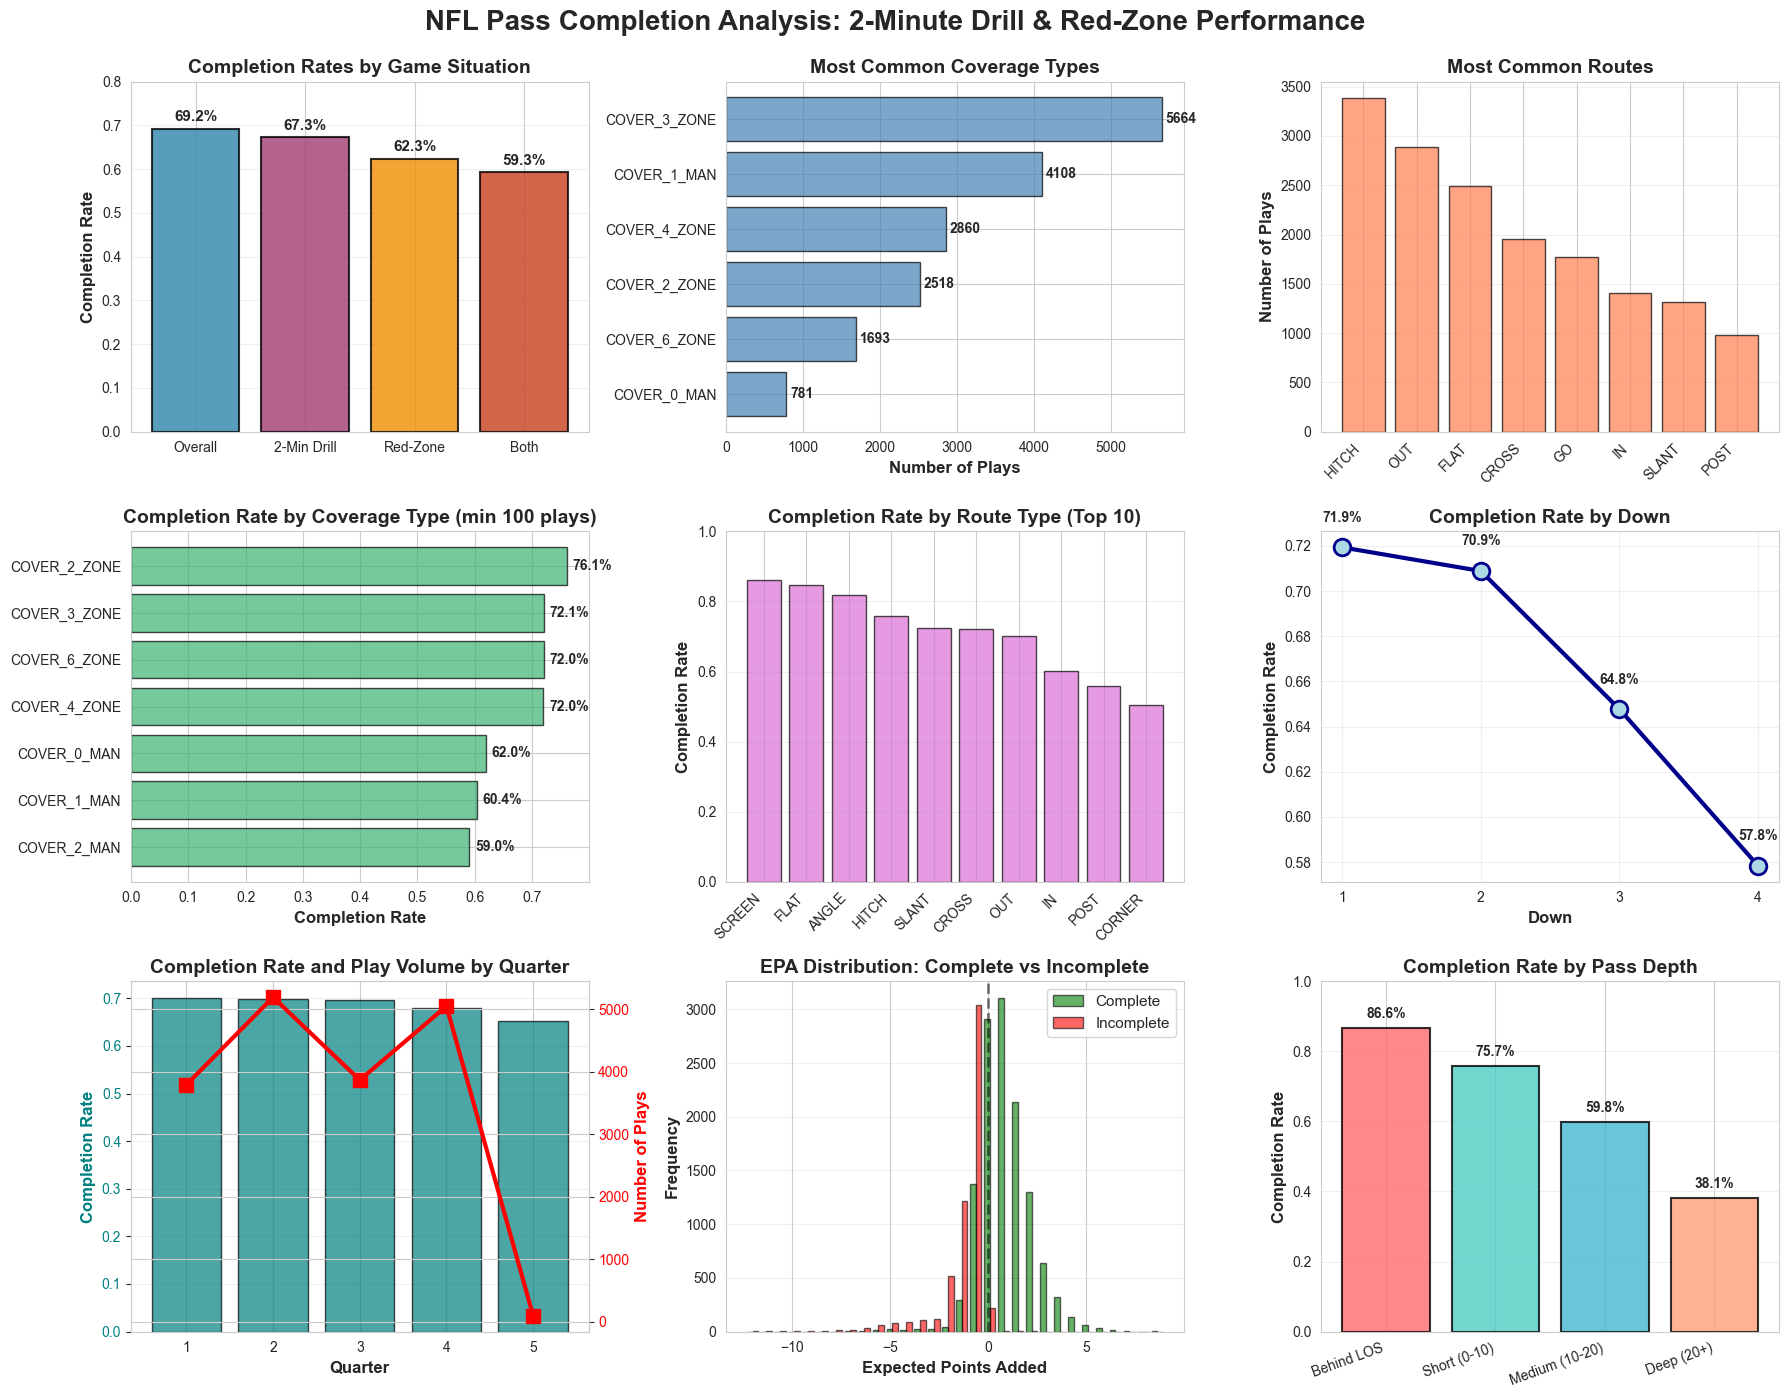

In [4]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('NFL Pass Completion Analysis: 2-Minute Drill & Red-Zone Performance', 
             fontsize=20, fontweight='bold', y=0.995)

# 1. Completion Rates by Situation
ax1 = axes[0, 0]
situations = ['Overall', '2-Min Drill', 'Red-Zone', 'Both']
completion_rates = [
    supp_data['is_completion'].mean(),
    supp_data[supp_data['is_two_minute_drill']]['is_completion'].mean(),
    supp_data[supp_data['is_redzone']]['is_completion'].mean(),
    supp_data[(supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])]['is_completion'].mean()
]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax1.bar(situations, completion_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax1.set_title('Completion Rates by Game Situation', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 0.8)
for i, (bar, rate) in enumerate(zip(bars, completion_rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{rate:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Coverage Type Distribution
ax2 = axes[0, 1]
coverage_counts = supp_data['team_coverage_type'].value_counts().head(6)
ax2.barh(coverage_counts.index, coverage_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Plays', fontsize=12, fontweight='bold')
ax2.set_title('Most Common Coverage Types', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(coverage_counts.values):
    ax2.text(v + 50, i, str(v), va='center', fontsize=10, fontweight='bold')

# 3. Route Distribution
ax3 = axes[0, 2]
route_counts = supp_data['route_of_targeted_receiver'].value_counts().head(8)
ax3.bar(range(len(route_counts)), route_counts.values, color='coral', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(route_counts)))
ax3.set_xticklabels(route_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Number of Plays', fontsize=12, fontweight='bold')
ax3.set_title('Most Common Routes', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Completion Rate by Coverage Type
ax4 = axes[1, 0]
coverage_completion = supp_data.groupby('team_coverage_type')['is_completion'].agg(['mean', 'count'])
coverage_completion = coverage_completion[coverage_completion['count'] >= 100].sort_values('mean', ascending=False)
ax4.barh(coverage_completion.index, coverage_completion['mean'], color='mediumseagreen', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Completion Rate', fontsize=12, fontweight='bold')
ax4.set_title('Completion Rate by Coverage Type (min 100 plays)', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(coverage_completion['mean']):
    ax4.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=10, fontweight='bold')

# 5. Completion Rate by Route
ax5 = axes[1, 1]
route_completion = supp_data.groupby('route_of_targeted_receiver')['is_completion'].agg(['mean', 'count'])
route_completion = route_completion[route_completion['count'] >= 100].sort_values('mean', ascending=False).head(10)
ax5.bar(range(len(route_completion)), route_completion['mean'], color='orchid', alpha=0.7, edgecolor='black')
ax5.set_xticks(range(len(route_completion)))
ax5.set_xticklabels(route_completion.index, rotation=45, ha='right')
ax5.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax5.set_title('Completion Rate by Route Type (Top 10)', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(axis='y', alpha=0.3)

# 6. Down and Distance Analysis
ax6 = axes[1, 2]
down_completion = supp_data.groupby('down')['is_completion'].mean()
ax6.plot(down_completion.index, down_completion.values, marker='o', linewidth=3, 
         markersize=12, color='darkblue', markerfacecolor='lightblue', markeredgewidth=2)
ax6.set_xlabel('Down', fontsize=12, fontweight='bold')
ax6.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax6.set_title('Completion Rate by Down', fontsize=14, fontweight='bold')
ax6.set_xticks([1, 2, 3, 4])
ax6.grid(True, alpha=0.3)
for x, y in zip(down_completion.index, down_completion.values):
    ax6.text(x, y + 0.01, f'{y:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 7. Quarter Analysis
ax7 = axes[2, 0]
quarter_data = supp_data.groupby('quarter').agg({
    'is_completion': 'mean',
    'play_id': 'count'
})
ax7_twin = ax7.twinx()
bars = ax7.bar(quarter_data.index, quarter_data['is_completion'], color='teal', alpha=0.7, 
               edgecolor='black', label='Completion Rate')
line = ax7_twin.plot(quarter_data.index, quarter_data['play_id'], color='red', marker='s', 
                     linewidth=3, markersize=10, label='Number of Plays')
ax7.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax7.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='teal')
ax7_twin.set_ylabel('Number of Plays', fontsize=12, fontweight='bold', color='red')
ax7.set_title('Completion Rate and Play Volume by Quarter', fontsize=14, fontweight='bold')
ax7.tick_params(axis='y', labelcolor='teal')
ax7_twin.tick_params(axis='y', labelcolor='red')
ax7.grid(axis='y', alpha=0.3)

# 8. Expected Points Added Distribution
ax8 = axes[2, 1]
epa_complete = supp_data[supp_data['is_completion'] == 1]['expected_points_added'].dropna()
epa_incomplete = supp_data[supp_data['is_completion'] == 0]['expected_points_added'].dropna()
ax8.hist([epa_complete, epa_incomplete], bins=30, label=['Complete', 'Incomplete'], 
         color=['green', 'red'], alpha=0.6, edgecolor='black')
ax8.set_xlabel('Expected Points Added', fontsize=12, fontweight='bold')
ax8.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax8.set_title('EPA Distribution: Complete vs Incomplete', fontsize=14, fontweight='bold')
ax8.legend(fontsize=11)
ax8.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax8.grid(axis='y', alpha=0.3)

# 9. Pass Length Analysis
ax9 = axes[2, 2]
pass_length_bins = pd.cut(supp_data['pass_length'], bins=[-50, 0, 10, 20, 100], 
                          labels=['Behind LOS', 'Short (0-10)', 'Medium (10-20)', 'Deep (20+)'])
length_completion = supp_data.groupby(pass_length_bins)['is_completion'].mean()
ax9.bar(range(len(length_completion)), length_completion.values, 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax9.set_xticks(range(len(length_completion)))
ax9.set_xticklabels(length_completion.index, rotation=20, ha='right')
ax9.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax9.set_title('Completion Rate by Pass Depth', fontsize=14, fontweight='bold')
ax9.set_ylim(0, 1)
for i, v in enumerate(length_completion.values):
    ax9.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../visualizations") / 'nfl_completion_analysis_overview.png', dpi=300, bbox_inches='tight')
print("Comprehensive analysis visualization saved!")
plt.show()

# Modeling:

### Two-Minute Drill:

In [5]:
# ============================================================================
# STEP 1: Data Formation
# ============================================================================
# Define the base path
BASE_PATH = Path('C:/Users/jrzem/Downloads/NFL-Big-Data-Bowl-2026-Analytics-Challenge/data/raw')

# Load supplementary data with two-minute drill flag
print("Loading supplementary data...")
supp_data = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\processed\\supplementary_enhanced.csv')
print(f"Supplementary data loaded: {supp_data.shape}")
print(f"Two-minute drill plays: {supp_data['is_two_minute_drill'].sum()}")

# Filter supplementary data to only two-minute drill plays
supp_data_2min = supp_data[supp_data['is_two_minute_drill'] == True].copy()
print(f"Filtered to two-minute drill plays only: {supp_data_2min.shape}")

# Load all weeks using pathlib for cross-platform compatibility
all_input_files = sorted(BASE_PATH.glob('input_2023_w*.csv'))

# Convert Path objects to strings for pandas
all_input_files = [str(f) for f in all_input_files]

print(f"\nFound {len(all_input_files)} input files")

if len(all_input_files) > 0:
    print("\nInput files found:")
    for f in all_input_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_input_files) > 5:
        print(f"  ... and {len(all_input_files) - 5} more")

# Define feature extraction function
def extract_comprehensive_features(df, week_num, supp_df):
    """Extract comprehensive features from tracking data"""
    features_list = []
    
    # Get unique plays
    plays = df.groupby(['game_id', 'play_id'])
    
    for (game_id, play_id), play_data in plays:
        # Check if this play exists in the filtered supplementary data (two-minute drill only)
        supp_play = supp_df[(supp_df['game_id'] == game_id) & (supp_df['play_id'] == play_id)]
        if len(supp_play) == 0:
            continue  # Skip plays that are not two-minute drill
        
        is_two_min = supp_play.iloc[0]['is_two_minute_drill']
        
        # Get last frame (before pass)
        last_frame = play_data['frame_id'].max()
        last_frame_data = play_data[play_data['frame_id'] == last_frame]
        
        # Get targeted receiver
        targeted = last_frame_data[last_frame_data['player_role'] == 'Targeted Receiver']
        if len(targeted) == 0:
            continue
            
        targeted = targeted.iloc[0]
        
        # Get passer
        passer = last_frame_data[last_frame_data['player_role'] == 'Passer']
        if len(passer) == 0:
            continue
        passer = passer.iloc[0]
        
        # Get defenders
        defenders = last_frame_data[last_frame_data['player_side'] == 'Defense']
        
        # Calculate features
        features = {
            'game_id': game_id,
            'play_id': play_id,
            'week': week_num,
            'is_two_minute_drill': is_two_min,
            
            # Receiver features
            'receiver_x': targeted['x'],
            'receiver_y': targeted['y'],
            'receiver_speed': targeted['s'],
            'receiver_acceleration': targeted['a'],
            'receiver_direction': targeted['dir'],
            'receiver_orientation': targeted['o'],
            
            # Passer features
            'passer_x': passer['x'],
            'passer_y': passer['y'],
            'passer_speed': passer['s'],
            
            # Ball landing
            'ball_land_x': targeted['ball_land_x'],
            'ball_land_y': targeted['ball_land_y'],
            
            # Distance calculations
            'dist_to_ball_land': np.sqrt((targeted['x'] - targeted['ball_land_x'])**2 + 
                                         (targeted['y'] - targeted['ball_land_y'])**2),
            'dist_from_passer': np.sqrt((targeted['x'] - passer['x'])**2 + 
                                       (targeted['y'] - passer['y'])**2),
            
            # Defender proximity
            'num_defenders': len(defenders),
            'closest_defender_dist': defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2), 
                axis=1
            ).min() if len(defenders) > 0 else np.nan,
            
            'avg_defender_dist': defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2), 
                axis=1
            ).mean() if len(defenders) > 0 else np.nan,
            
            # Defenders within radius
            'defenders_within_5yds': sum(defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2) <= 5, 
                axis=1
            )) if len(defenders) > 0 else 0,
            
            'defenders_within_10yds': sum(defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2) <= 10, 
                axis=1
            )) if len(defenders) > 0 else 0,
        }
        
        # Trajectory analysis - look at last 5 frames
        receiver_id = targeted['nfl_id']
        receiver_trajectory = play_data[
            (play_data['nfl_id'] == receiver_id) & 
            (play_data['frame_id'] >= max(1, last_frame - 4))
        ].sort_values('frame_id')
        
        if len(receiver_trajectory) >= 2:
            # Speed change
            features['speed_change'] = receiver_trajectory['s'].iloc[-1] - receiver_trajectory['s'].iloc[0]
            features['max_speed'] = receiver_trajectory['s'].max()
            features['avg_speed'] = receiver_trajectory['s'].mean()
            
            # Direction change
            features['direction_change'] = abs(receiver_trajectory['dir'].iloc[-1] - receiver_trajectory['dir'].iloc[0])
            
            # Distance covered
            positions = receiver_trajectory[['x', 'y']].values
            features['distance_covered'] = sum(
                np.sqrt(np.sum((positions[i] - positions[i-1])**2)) 
                for i in range(1, len(positions))
            )
        else:
            features['speed_change'] = 0
            features['max_speed'] = targeted['s']
            features['avg_speed'] = targeted['s']
            features['direction_change'] = 0
            features['distance_covered'] = 0
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

# Process all weeks
if len(all_input_files) > 0:
    print("\n" + "="*60)
    print("PROCESSING ALL INPUT FILES (TWO-MINUTE DRILL ONLY)")
    print("="*60)
    all_features = []
    
    for input_file in all_input_files:
        filename = Path(input_file).name
        # Extract week number from filename (e.g., input_2023_w01.csv -> 1)
        week_num = int(filename.split('_w')[1].split('.')[0])
        
        try:
            print(f"\nProcessing {filename} (Week {week_num})...")
            df = pd.read_csv(input_file)
            week_features = extract_comprehensive_features(df, week_num, supp_data_2min)
            all_features.append(week_features)
            print(f"  ✓ Extracted {len(week_features)} two-minute drill plays from week {week_num}")
        except FileNotFoundError:
            print(f"  ✗ {filename} not found, skipping...")
        except Exception as e:
            print(f"  ✗ Error processing {filename}: {e}")
    
    # Combine all features
    if len(all_features) > 0:
        tracking_features = pd.concat(all_features, ignore_index=True)
        print("\n" + "="*60)
        print("FEATURE EXTRACTION COMPLETE")
        print("="*60)
        print(f"Total tracking features extracted: {tracking_features.shape}")
        print(f"Columns: {len(tracking_features.columns)}")
        print(f"\nColumn names:")
        for i, col in enumerate(tracking_features.columns.tolist(), 1):
            print(f"  {i:2d}. {col}")
        
        # Summary of two-minute drill plays
        print("\n" + "="*60)
        print("TWO-MINUTE DRILL SUMMARY")
        print("="*60)
        print(f"Two-minute drill plays in tracking features: {tracking_features['is_two_minute_drill'].sum()}")
        print(f"Total plays: {len(tracking_features)}")
        print(f"Percentage: {tracking_features['is_two_minute_drill'].mean()*100:.1f}%")
        print("(Should be 100% since we filtered for two-minute drill only)")
        
        # Merge tracking features with supplementary data (two-minute drill only)
        print("\n" + "="*60)
        print("MERGING WITH SUPPLEMENTARY DATA (TWO-MINUTE DRILL ONLY)")
        print("="*60)
        merged_data = tracking_features.merge(
            supp_data_2min, 
            on=['game_id', 'play_id'], 
            how='inner',
            suffixes=('_tracking', '_supp')  # Use clearer suffixes
        )
        
        print(f"Merged data shape: {merged_data.shape}")
        
        # Clean up duplicate columns - keep tracking version for week and is_two_minute_drill
        if 'week_tracking' in merged_data.columns and 'week_supp' in merged_data.columns:
            merged_data['week'] = merged_data['week_tracking']
            merged_data.drop(['week_tracking', 'week_supp'], axis=1, inplace=True)
        
        if 'is_two_minute_drill_tracking' in merged_data.columns and 'is_two_minute_drill_supp' in merged_data.columns:
            merged_data['is_two_minute_drill'] = merged_data['is_two_minute_drill_tracking']
            merged_data.drop(['is_two_minute_drill_tracking', 'is_two_minute_drill_supp'], axis=1, inplace=True)
        
        # Verify all plays are two-minute drill
        print(f"\nVerification: All plays are two-minute drill? {merged_data['is_two_minute_drill'].all()}")
        
        # Check for missing values
        missing_vals = merged_data.isnull().sum()
        missing_vals = missing_vals[missing_vals > 0]
        if len(missing_vals) > 0:
            print(f"\nMissing values:")
            for col, count in missing_vals.items():
                print(f"  - {col}: {count} ({count/len(merged_data)*100:.1f}%)")
        else:
            print("\n✓ No missing values!")
        
        # Save merged data
        merged_data.to_csv('Two-Minute Drill/comprehensive_analysis_data_2min_drill.csv', index=False)
        print("\n✓ Saved comprehensive_analysis_data_2min_drill.csv")
        
        # Display summary statistics
        print("\n" + "="*60)
        print("DATA SUMMARY (TWO-MINUTE DRILL ONLY)")
        print("="*60)
        print(f"Total plays: {len(merged_data)}")
        print(f"Completion rate: {merged_data['is_completion'].mean():.3f}")
        print(f"Weeks covered: {sorted(merged_data['week'].unique())}")
        print(f"\nKey features available:")
        print(f"  - Tracking features: {len(tracking_features.columns)}")
        print(f"  - Supplementary features: {len(supp_data_2min.columns)}")
        print(f"  - Total merged features: {len(merged_data.columns)}")
        
        # Additional two-minute drill statistics
        print(f"\nTwo-Minute Drill Statistics:")
        print(f"  - Total two-minute drill plays: {len(merged_data)}")
        print(f"  - Completion rate: {merged_data['is_completion'].mean():.3f}")
        print(f"  - Average EPA: {merged_data['expected_points_added'].mean():.3f}")
        print(f"  - Average pass length: {merged_data['pass_length'].mean():.2f} yards")
        
        # Quarter breakdown
        print(f"\nQuarter Breakdown:")
        quarter_stats = merged_data.groupby('quarter').agg({
            'play_id': 'count',
            'is_completion': 'mean',
            'expected_points_added': 'mean'
        }).round(3)
        quarter_stats.columns = ['Plays', 'Completion Rate', 'Avg EPA']
        print(quarter_stats)
        
    else:
        print("\n❌ No features extracted from any files.")
else:
    print("\n❌ No input files found. Please check the BASE_PATH.")

Loading supplementary data...
Supplementary data loaded: (18009, 46)
Two-minute drill plays: 2762
Filtered to two-minute drill plays only: (2762, 46)

Found 18 input files

Input files found:
  - input_2023_w01.csv
  - input_2023_w02.csv
  - input_2023_w03.csv
  - input_2023_w04.csv
  - input_2023_w05.csv
  ... and 13 more

PROCESSING ALL INPUT FILES (TWO-MINUTE DRILL ONLY)

Processing input_2023_w01.csv (Week 1)...
  ✓ Extracted 129 two-minute drill plays from week 1

Processing input_2023_w02.csv (Week 2)...
  ✓ Extracted 133 two-minute drill plays from week 2

Processing input_2023_w03.csv (Week 3)...
  ✓ Extracted 136 two-minute drill plays from week 3

Processing input_2023_w04.csv (Week 4)...
  ✓ Extracted 112 two-minute drill plays from week 4

Processing input_2023_w05.csv (Week 5)...
  ✓ Extracted 113 two-minute drill plays from week 5

Processing input_2023_w06.csv (Week 6)...
  ✓ Extracted 128 two-minute drill plays from week 6

Processing input_2023_w07.csv (Week 7)...
  ✓ 

In [6]:
# ============================================================================
# STEP 2: PREDICTIVE MODELING
# ============================================================================

print("="*80)
print("STEP 2: PREDICTIVE MODELING - COMPLETION PROBABILITY")
print("="*80)

# Prepare data for modeling
model_data = merged_data.copy()

# Select features for modeling
feature_cols = [
    'receiver_speed', 'receiver_acceleration', 'receiver_direction',
    'passer_speed', 'dist_to_ball_land', 'dist_from_passer',
    'closest_defender_dist', 'avg_defender_dist', 
    'defenders_within_5yds', 'defenders_within_10yds',
    'speed_change', 'max_speed', 'avg_speed', 'direction_change',
    'distance_covered', 'down', 'yards_to_go', 'quarter',
    'defenders_in_the_box', 'pass_length', 'dropback_distance',
    'yardline_number', 'yards_to_endzone',
    'is_two_minute_drill', 'is_redzone', 'play_action'
]

# Encode categorical variables
le_coverage = LabelEncoder()
le_route = LabelEncoder()
le_formation = LabelEncoder()

model_data['coverage_encoded'] = le_coverage.fit_transform(
    model_data['team_coverage_type'].fillna('Unknown')
)
model_data['route_encoded'] = le_route.fit_transform(
    model_data['route_of_targeted_receiver'].fillna('Unknown')
)
model_data['formation_encoded'] = le_formation.fit_transform(
    model_data['offense_formation'].fillna('Unknown')
)

feature_cols.extend(['coverage_encoded', 'route_encoded', 'formation_encoded'])

# Prepare X and y
X = model_data[feature_cols].fillna(0)
y = model_data['is_completion']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Completion rate in train: {y_train.mean():.3f}")
print(f"Completion rate in test: {y_test.mean():.3f}")

# Train multiple models
print("\n" + "="*60)
print("Training Models...")
print("="*60)

# 1. Logistic Regression
print("\n1. Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred_proba)
print(f"   AUC: {lr_auc:.4f}")
print(f"   Accuracy: {(lr_pred == y_test).mean():.4f}")

# 2. Random Forest
print("\n2. Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred_proba)
print(f"   AUC: {rf_auc:.4f}")
print(f"   Accuracy: {(rf_pred == y_test).mean():.4f}")

# 3. Gradient Boosting
print("\n3. Gradient Boosting")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_pred_proba = gb_model.predict_proba(X_test)[:, 1]
gb_auc = roc_auc_score(y_test, gb_pred_proba)
print(f"   AUC: {gb_auc:.4f}")
print(f"   Accuracy: {(gb_pred == y_test).mean():.4f}")

# Select best model
best_model = gb_model
best_pred_proba = gb_pred_proba

print("\n" + "="*60)
print("Best Model: Gradient Boosting")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=['Incomplete', 'Complete']))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Save predictions
model_data['completion_probability'] = np.nan
test_indices = X_test.index
model_data.loc[test_indices, 'completion_probability'] = best_pred_proba

# Save model results
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'AUC': [lr_auc, rf_auc, gb_auc],
    'Accuracy': [
        (lr_pred == y_test).mean(),
        (rf_pred == y_test).mean(),
        (gb_pred == y_test).mean()
    ]
})

print("\n" + "="*60)
print("Model Comparison:")
print("="*60)
print(model_results.to_string(index=False))

# Save feature importance
feature_importance.to_csv('Two-Minute Drill/feature_importance_two_minute.csv', index=False)
print("\nSaved feature_importance.csv")

STEP 2: PREDICTIVE MODELING - COMPLETION PROBABILITY

Training set: (1707, 29)
Test set: (427, 29)
Completion rate in train: 0.677
Completion rate in test: 0.677

Training Models...

1. Logistic Regression
   AUC: 0.7826
   Accuracy: 0.7635

2. Random Forest
   AUC: 0.7761
   Accuracy: 0.7424

3. Gradient Boosting
   AUC: 0.7644
   Accuracy: 0.7775

Best Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

  Incomplete       0.72      0.51      0.60       138
    Complete       0.79      0.91      0.85       289

    accuracy                           0.78       427
   macro avg       0.76      0.71      0.72       427
weighted avg       0.77      0.78      0.77       427


Top 15 Most Important Features:
              feature  importance
    dist_to_ball_land    0.253240
closest_defender_dist    0.132938
         passer_speed    0.058161
    avg_defender_dist    0.056008
     direction_change    0.046515
     dist_from_passer    0.040

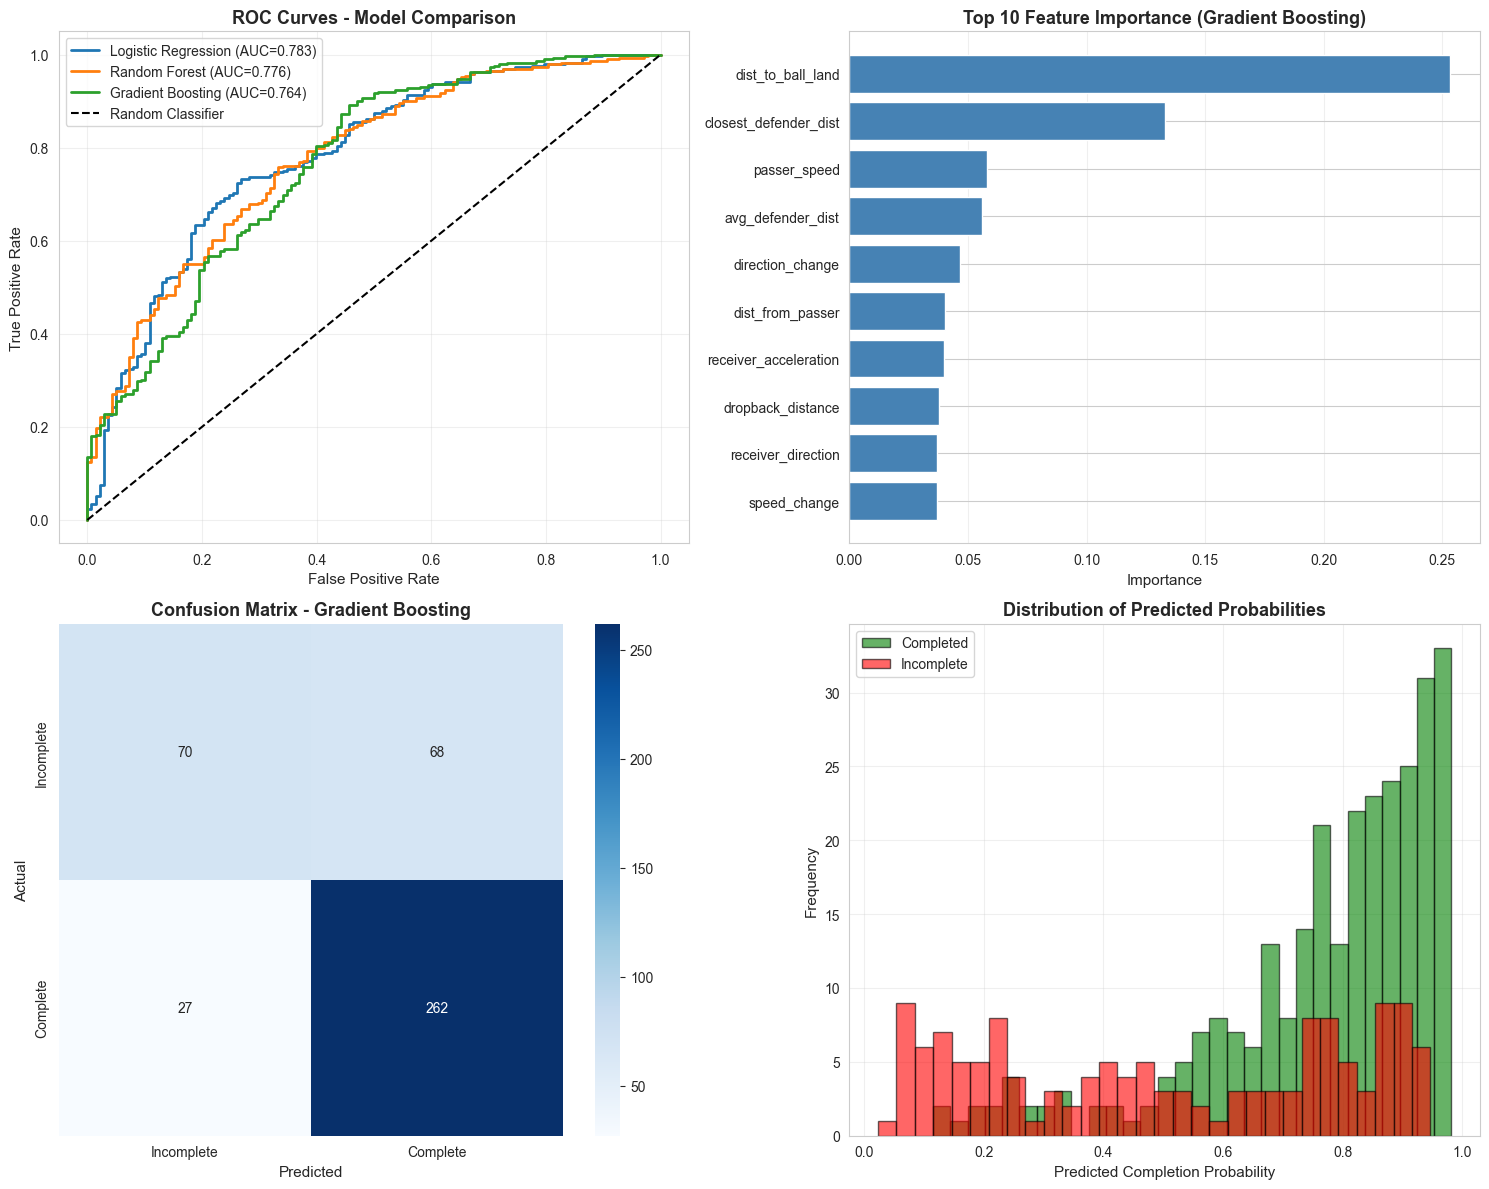

Saved predictive_modeling_results_two_minute.png


In [7]:
# Create visualizations for predictive modeling
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curves
ax = axes[0, 0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_pred_proba)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=2)
ax.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={gb_auc:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 2. Feature Importance
ax = axes[0, 1]
top_features = feature_importance.head(10)
ax.barh(range(len(top_features)), top_features['importance'], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Top 10 Feature Importance (Gradient Boosting)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# 3. Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Incomplete', 'Complete'],
            yticklabels=['Incomplete', 'Complete'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix - Gradient Boosting', fontsize=13, fontweight='bold')

# 4. Predicted Probability Distribution
ax = axes[1, 1]
completed = y_test == 1
ax.hist(best_pred_proba[completed], bins=30, alpha=0.6, label='Completed', color='green', edgecolor='black')
ax.hist(best_pred_proba[~completed], bins=30, alpha=0.6, label='Incomplete', color='red', edgecolor='black')
ax.set_xlabel('Predicted Completion Probability', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Predicted Probabilities', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Two-Minute Drill/predictive_modeling_results_two_minute.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved predictive_modeling_results_two_minute.png")

STEP 3: ADVANCED SPATIAL ANALYSIS


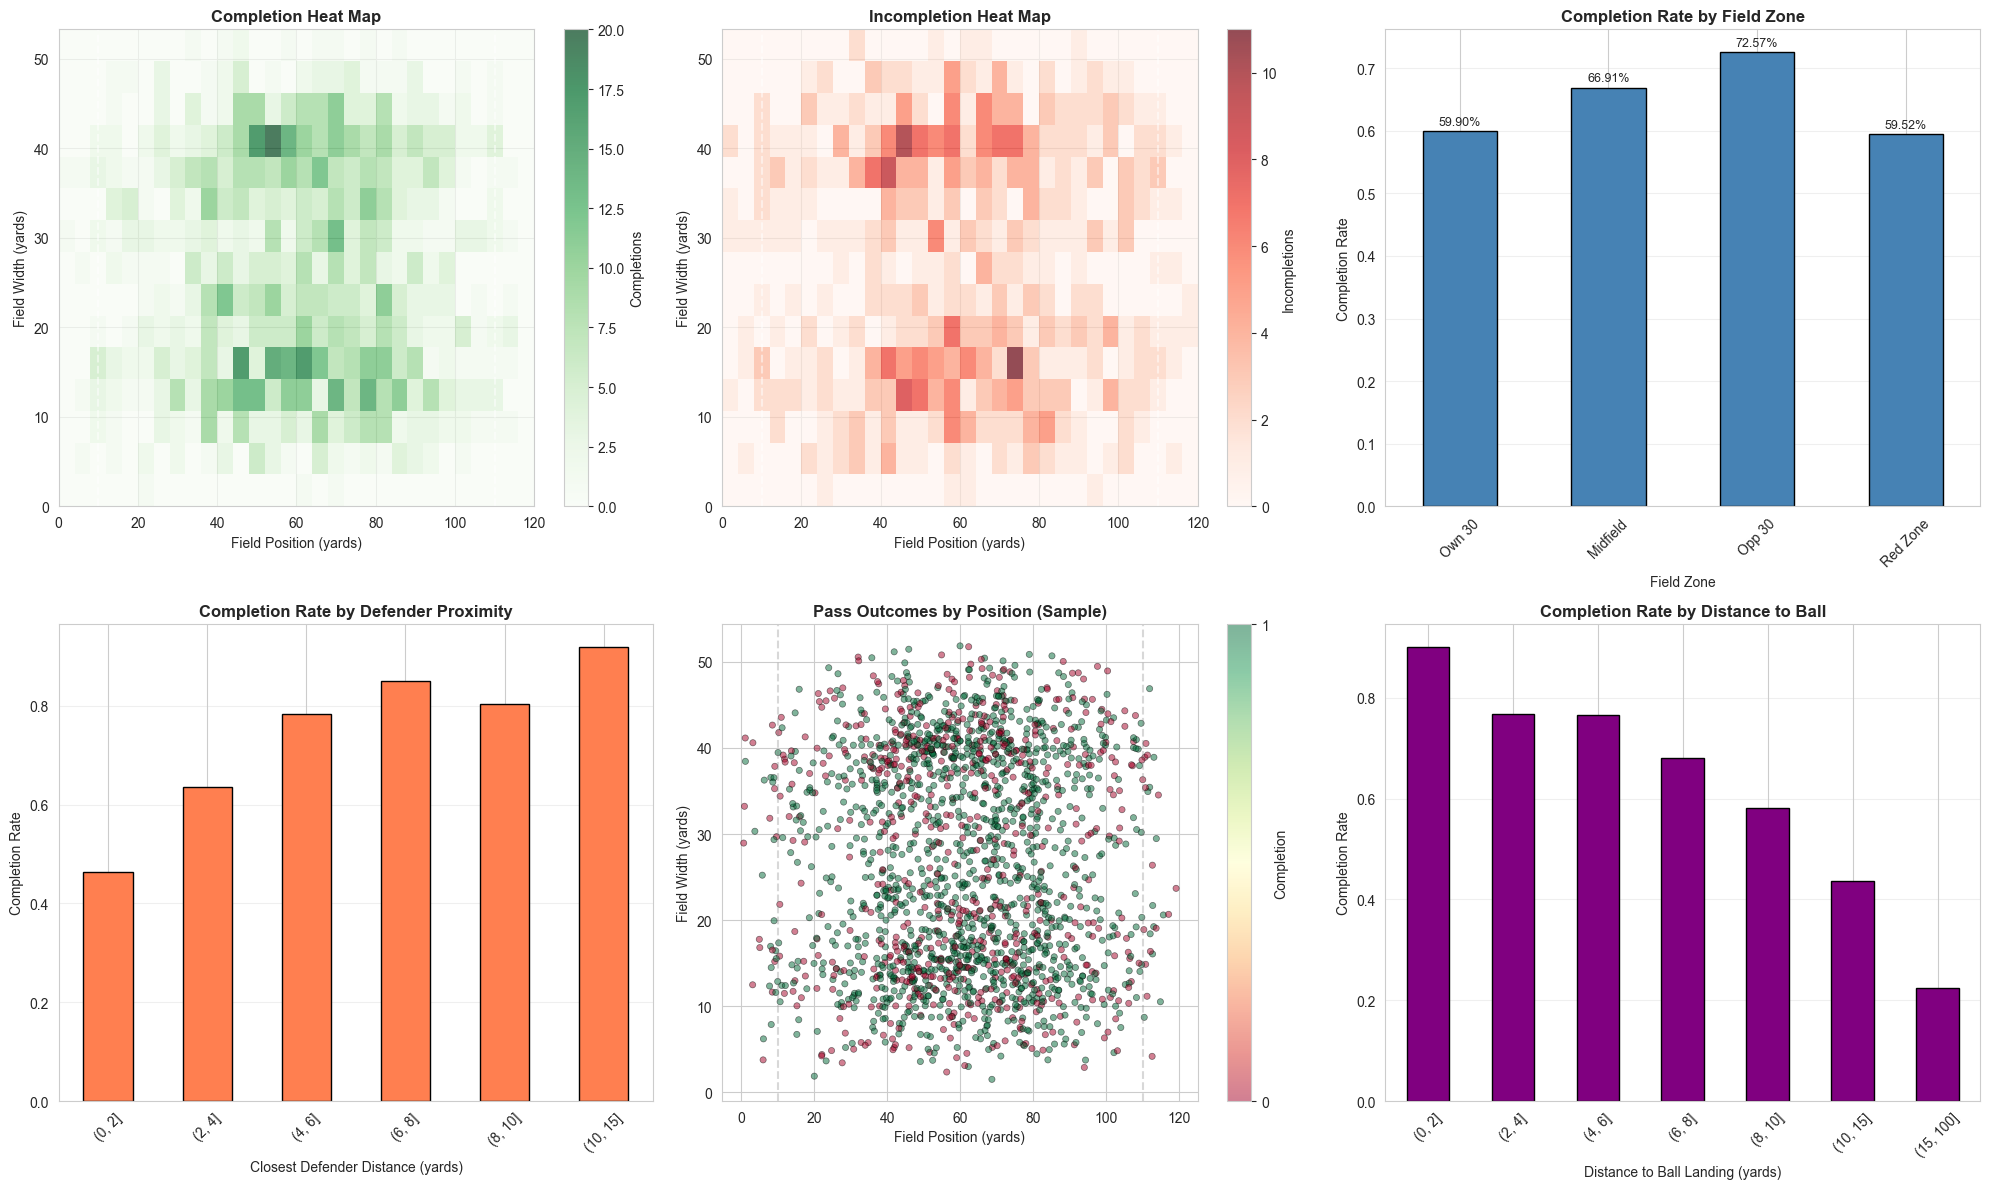


Saved spatial_analysis.png

SPATIAL ANALYSIS INSIGHTS

Completion Rate by Field Zone:
                mean  count
field_zone                 
Own 30      0.599010    202
Midfield    0.669118    816
Opp 30      0.725694    864
Red Zone    0.595238    252

Completion Rate by Defender Proximity:
                        mean  count
defender_proximity                 
(0, 2]              0.464413    562
(2, 4]              0.635750    593
(4, 6]              0.784091    440
(6, 8]              0.851064    235
(8, 10]             0.804511    133
(10, 15]            0.919463    149


In [8]:
# ============================================================================
# STEP 3: ADVANCED SPATIAL ANALYSIS
# ============================================================================

print("="*80)
print("STEP 3: ADVANCED SPATIAL ANALYSIS")
print("="*80)

# Create spatial visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Completion Heat Map by Field Position
ax1 = plt.subplot(2, 3, 1)
completed_plays = model_data[model_data['is_completion'] == 1]
incomplete_plays = model_data[model_data['is_completion'] == 0]

# Create 2D histogram for completions
h_complete = ax1.hist2d(completed_plays['receiver_x'], completed_plays['receiver_y'], 
                         bins=[30, 15], cmap='Greens', alpha=0.7, range=[[0, 120], [0, 53.3]])
ax1.set_xlabel('Field Position (yards)', fontsize=10)
ax1.set_ylabel('Field Width (yards)', fontsize=10)
ax1.set_title('Completion Heat Map', fontsize=12, fontweight='bold')
ax1.axvline(x=10, color='white', linestyle='--', alpha=0.5, label='End Zone')
ax1.axvline(x=110, color='white', linestyle='--', alpha=0.5)
plt.colorbar(h_complete[3], ax=ax1, label='Completions')

# 2. Incompletion Heat Map
ax2 = plt.subplot(2, 3, 2)
h_incomplete = ax2.hist2d(incomplete_plays['receiver_x'], incomplete_plays['receiver_y'], 
                           bins=[30, 15], cmap='Reds', alpha=0.7, range=[[0, 120], [0, 53.3]])
ax2.set_xlabel('Field Position (yards)', fontsize=10)
ax2.set_ylabel('Field Width (yards)', fontsize=10)
ax2.set_title('Incompletion Heat Map', fontsize=12, fontweight='bold')
ax2.axvline(x=10, color='white', linestyle='--', alpha=0.5)
ax2.axvline(x=110, color='white', linestyle='--', alpha=0.5)
plt.colorbar(h_incomplete[3], ax=ax2, label='Incompletions')

# 3. Completion Rate by Field Zone
ax3 = plt.subplot(2, 3, 3)
model_data['field_zone'] = pd.cut(model_data['receiver_x'], bins=[0, 30, 60, 90, 120], 
                                    labels=['Own 30', 'Midfield', 'Opp 30', 'Red Zone'])
zone_completion = model_data.groupby('field_zone')['is_completion'].agg(['mean', 'count'])
zone_completion['mean'].plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black')
ax3.set_xlabel('Field Zone', fontsize=10)
ax3.set_ylabel('Completion Rate', fontsize=10)
ax3.set_title('Completion Rate by Field Zone', fontsize=12, fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(zone_completion['mean']):
    ax3.text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=9)

# 4. Defender Proximity Analysis
ax4 = plt.subplot(2, 3, 4)
proximity_bins = [0, 2, 4, 6, 8, 10, 15, 50]
model_data['defender_proximity'] = pd.cut(model_data['closest_defender_dist'], bins=proximity_bins)
proximity_completion = model_data.groupby('defender_proximity')['is_completion'].agg(['mean', 'count'])
proximity_completion = proximity_completion[proximity_completion['count'] > 50]
proximity_completion['mean'].plot(kind='bar', ax=ax4, color='coral', edgecolor='black')
ax4.set_xlabel('Closest Defender Distance (yards)', fontsize=10)
ax4.set_ylabel('Completion Rate', fontsize=10)
ax4.set_title('Completion Rate by Defender Proximity', fontsize=12, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
ax4.grid(axis='y', alpha=0.3)

# 5. Coverage Zones - Scatter Plot
ax5 = plt.subplot(2, 3, 5)
sample_data = model_data.sample(min(2000, len(model_data)), random_state=42)
scatter = ax5.scatter(sample_data['receiver_x'], sample_data['receiver_y'], 
                      c=sample_data['is_completion'], cmap='RdYlGn', 
                      alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
ax5.set_xlabel('Field Position (yards)', fontsize=10)
ax5.set_ylabel('Field Width (yards)', fontsize=10)
ax5.set_title('Pass Outcomes by Position (Sample)', fontsize=12, fontweight='bold')
ax5.axvline(x=10, color='gray', linestyle='--', alpha=0.3)
ax5.axvline(x=110, color='gray', linestyle='--', alpha=0.3)
plt.colorbar(scatter, ax=ax5, label='Completion', ticks=[0, 1])

# 6. Distance to Ball Landing vs Completion
ax6 = plt.subplot(2, 3, 6)
dist_bins = [0, 2, 4, 6, 8, 10, 15, 100]
model_data['dist_to_ball_bin'] = pd.cut(model_data['dist_to_ball_land'], bins=dist_bins)
dist_completion = model_data.groupby('dist_to_ball_bin')['is_completion'].agg(['mean', 'count'])
dist_completion = dist_completion[dist_completion['count'] > 50]
dist_completion['mean'].plot(kind='bar', ax=ax6, color='purple', edgecolor='black')
ax6.set_xlabel('Distance to Ball Landing (yards)', fontsize=10)
ax6.set_ylabel('Completion Rate', fontsize=10)
ax6.set_title('Completion Rate by Distance to Ball', fontsize=12, fontweight='bold')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Two-Minute Drill/spatial_analysis_two_minute.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved spatial_analysis.png")

# Print spatial insights
print("\n" + "="*60)
print("SPATIAL ANALYSIS INSIGHTS")
print("="*60)
print("\nCompletion Rate by Field Zone:")
print(zone_completion.to_string())
print("\nCompletion Rate by Defender Proximity:")
print(proximity_completion.to_string())

✓ Saved temporal_analysis_2min_drill.png


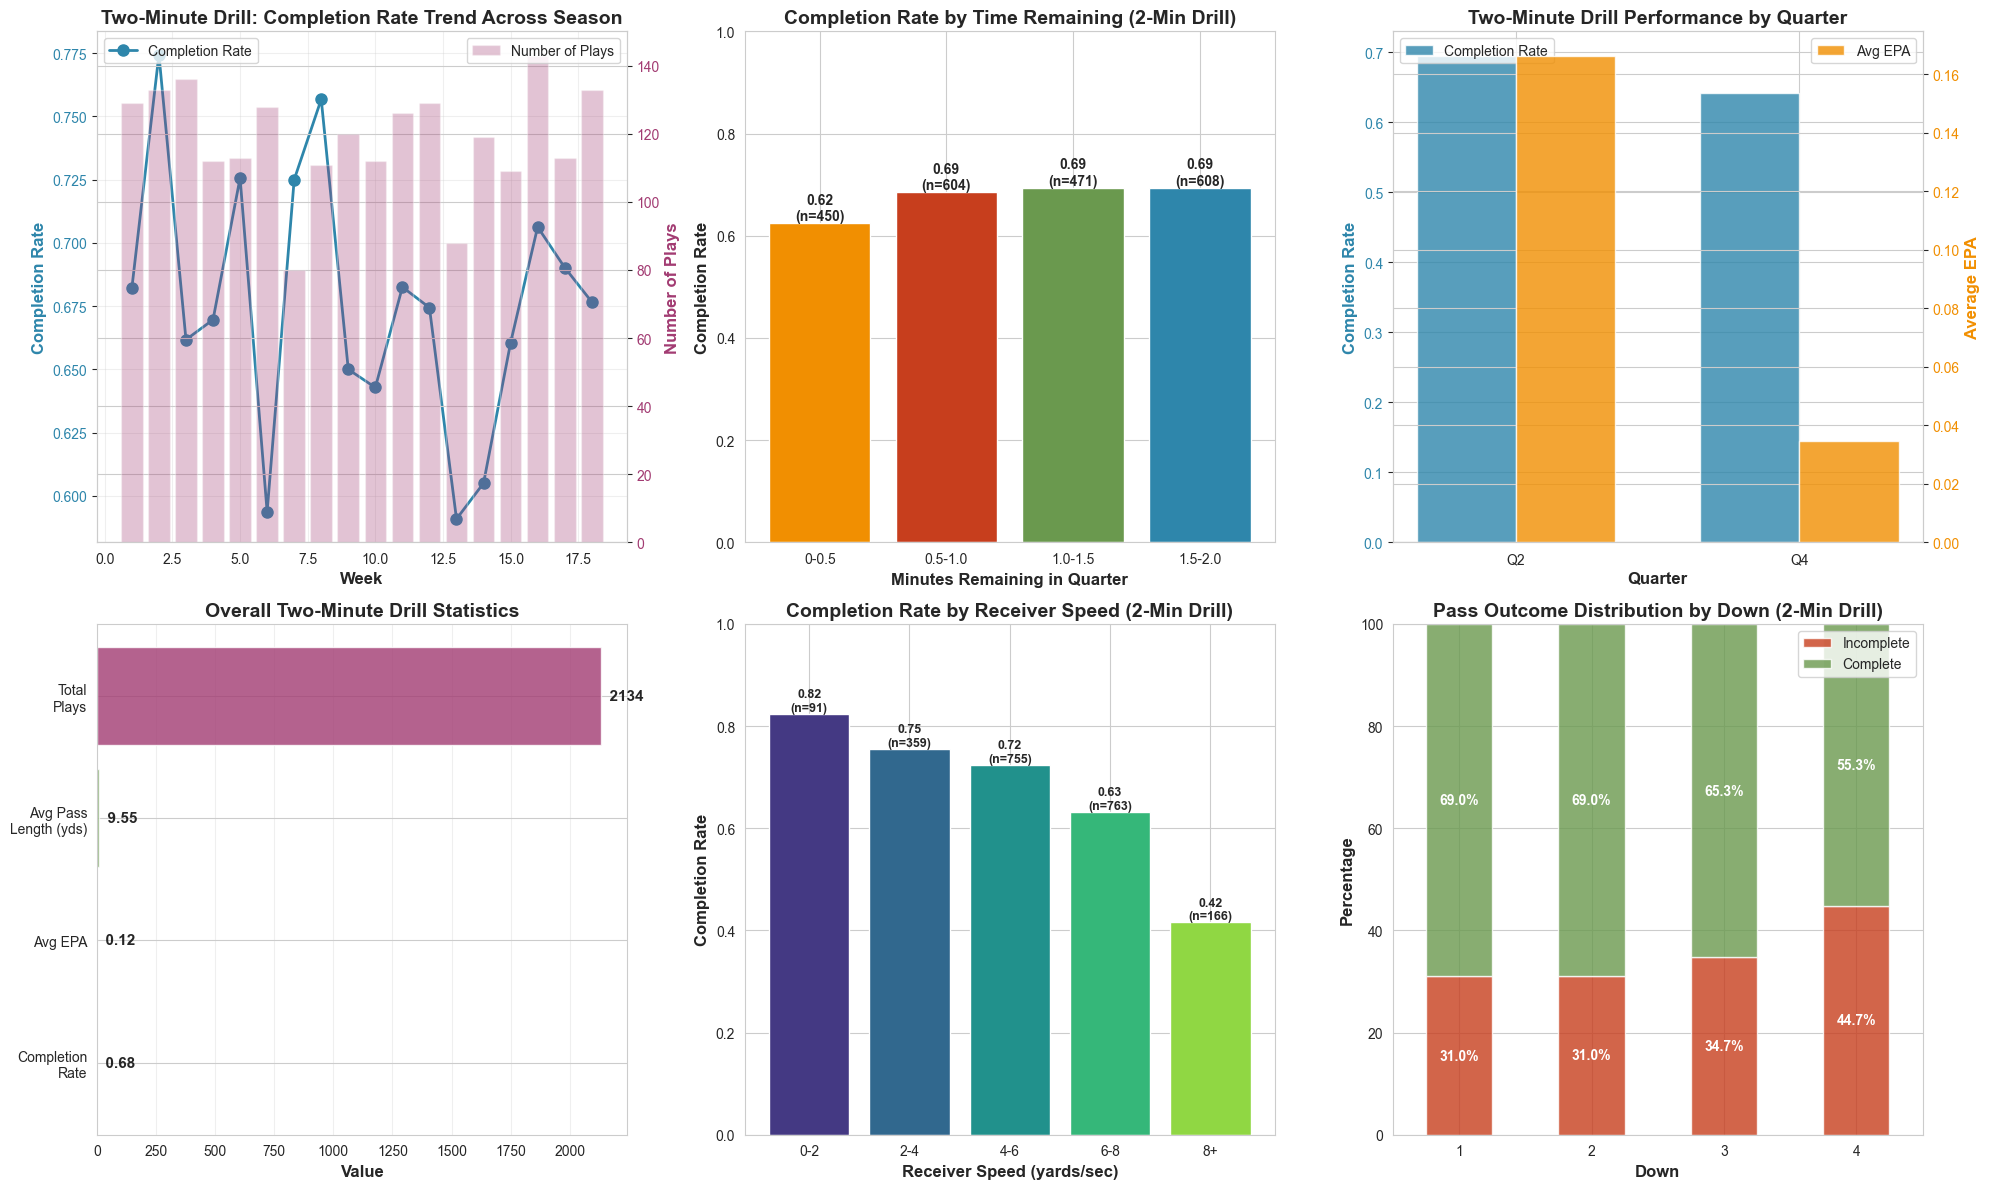


KEY TEMPORAL INSIGHTS (TWO-MINUTE DRILL)

1. Weekly Trends:
   - Highest completion rate: Week 2 (0.774)
   - Lowest completion rate: Week 13 (0.591)
   - Most active week: Week 16 (143 plays)

2. Time Pressure:
   - Completion rate with <30 seconds: 0.624
   - Completion rate with 1.5-2 minutes: 0.694

3. Quarter Analysis:
   - Q2: 0.695 completion rate, 0.166 EPA (1385 plays)
   - Q4: 0.642 completion rate, 0.035 EPA (749 plays)

4. Receiver Speed Impact:
   - Highest completion with speed: 0-2 yds/sec (0.824)
   - Lowest completion with speed: 8+ yds/sec (0.416)


In [9]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

# Create comprehensive temporal analysis
fig = plt.figure(figsize=(20, 12))

# 1. Completion Rate Trend Across Season
ax1 = plt.subplot(2, 3, 1)
weekly_stats = model_data.groupby('week').agg({
    'is_completion': 'mean',
    'play_id': 'count'
}).reset_index()
weekly_stats.columns = ['week', 'completion_rate', 'num_plays']

ax1_twin = ax1.twinx()
ax1.plot(weekly_stats['week'], weekly_stats['completion_rate'], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB', label='Completion Rate')
ax1_twin.bar(weekly_stats['week'], weekly_stats['num_plays'], 
             alpha=0.3, color='#A23B72', label='Number of Plays')

ax1.set_xlabel('Week', fontsize=12, fontweight='bold')
ax1.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='#2E86AB')
ax1_twin.set_ylabel('Number of Plays', fontsize=12, fontweight='bold', color='#A23B72')
ax1.set_title('Two-Minute Drill: Completion Rate Trend Across Season', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1_twin.tick_params(axis='y', labelcolor='#A23B72')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 2. Completion Rate by Game Clock
ax2 = plt.subplot(2, 3, 2)
# Convert game_clock to minutes remaining
def parse_game_clock(clock_str):
    try:
        parts = clock_str.split(':')
        return int(parts[0]) + int(parts[1])/60
    except:
        return np.nan

model_data['minutes_remaining'] = model_data['game_clock'].apply(parse_game_clock)
model_data['time_bin'] = pd.cut(model_data['minutes_remaining'], 
                                 bins=[0, 0.5, 1.0, 1.5, 2.0], 
                                 labels=['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0'])

time_stats = model_data.groupby('time_bin', observed=True).agg({
    'is_completion': 'mean',
    'play_id': 'count'
}).reset_index()

bars = ax2.bar(range(len(time_stats)), time_stats['is_completion'], 
               color=['#F18F01', '#C73E1D', '#6A994E', '#2E86AB'])
ax2.set_xticks(range(len(time_stats)))
ax2.set_xticklabels(time_stats['time_bin'], rotation=0)
ax2.set_xlabel('Minutes Remaining in Quarter', fontsize=12, fontweight='bold')
ax2.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax2.set_title('Completion Rate by Time Remaining (2-Min Drill)', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])

# Add value labels on bars
for i, (bar, val, count) in enumerate(zip(bars, time_stats['is_completion'], time_stats['play_id'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}\n(n={count})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Performance by Quarter
ax3 = plt.subplot(2, 3, 3)
quarter_stats = model_data.groupby('quarter').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).reset_index()

x = np.arange(len(quarter_stats))
width = 0.35

bars1 = ax3.bar(x - width/2, quarter_stats['is_completion'], width, 
                label='Completion Rate', color='#2E86AB', alpha=0.8)
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, quarter_stats['expected_points_added'], width,
                     label='Avg EPA', color='#F18F01', alpha=0.8)

ax3.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax3.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='#2E86AB')
ax3_twin.set_ylabel('Average EPA', fontsize=12, fontweight='bold', color='#F18F01')
ax3.set_title('Two-Minute Drill Performance by Quarter', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Q{int(q)}' for q in quarter_stats['quarter']])
ax3.tick_params(axis='y', labelcolor='#2E86AB')
ax3_twin.tick_params(axis='y', labelcolor='#F18F01')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. Two-Minute Drill Statistics (Since all plays are 2-min drill, show overall stats)
ax4 = plt.subplot(2, 3, 4)
overall_stats = pd.DataFrame({
    'Metric': ['Completion\nRate', 'Avg EPA', 'Avg Pass\nLength (yds)', 'Total\nPlays'],
    'Value': [
        model_data['is_completion'].mean(),
        model_data['expected_points_added'].mean(),
        model_data['pass_length'].mean(),
        len(model_data)
    ]
})

colors = ['#2E86AB', '#F18F01', '#6A994E', '#A23B72']
bars = ax4.barh(overall_stats['Metric'], overall_stats['Value'], color=colors, alpha=0.8)

ax4.set_xlabel('Value', fontsize=12, fontweight='bold')
ax4.set_title('Overall Two-Minute Drill Statistics', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, overall_stats['Value'])):
    if i == 3:  # Total plays
        label = f'{int(val)}'
    else:
        label = f'{val:.2f}'
    ax4.text(val, bar.get_y() + bar.get_height()/2., f'  {label}',
             ha='left', va='center', fontsize=11, fontweight='bold')

# 5. Completion Rate by Receiver Speed
ax5 = plt.subplot(2, 3, 5)
model_data['speed_bin'] = pd.cut(model_data['receiver_speed'], 
                                  bins=[0, 2, 4, 6, 8, 15],
                                  labels=['0-2', '2-4', '4-6', '6-8', '8+'])

speed_stats = model_data.groupby('speed_bin', observed=True).agg({
    'is_completion': 'mean',
    'play_id': 'count'
}).reset_index()

bars = ax5.bar(range(len(speed_stats)), speed_stats['is_completion'],
               color=sns.color_palette("viridis", len(speed_stats)))
ax5.set_xticks(range(len(speed_stats)))
ax5.set_xticklabels(speed_stats['speed_bin'], rotation=0)
ax5.set_xlabel('Receiver Speed (yards/sec)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax5.set_title('Completion Rate by Receiver Speed (2-Min Drill)', fontsize=14, fontweight='bold')
ax5.set_ylim([0, 1])

# Add value labels
for bar, val, count in zip(bars, speed_stats['is_completion'], speed_stats['play_id']):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}\n(n={count})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Completion vs Incompletion by Down
ax6 = plt.subplot(2, 3, 6)
down_stats = model_data.groupby(['down', 'is_completion']).size().unstack(fill_value=0)
down_stats_pct = down_stats.div(down_stats.sum(axis=1), axis=0) * 100

down_stats_pct.plot(kind='bar', stacked=True, ax=ax6, 
                    color=['#C73E1D', '#6A994E'], alpha=0.8)
ax6.set_xlabel('Down', fontsize=12, fontweight='bold')
ax6.set_ylabel('Percentage', fontsize=12, fontweight='bold')
ax6.set_title('Pass Outcome Distribution by Down (2-Min Drill)', fontsize=14, fontweight='bold')
ax6.set_xticklabels([f'{int(d)}' for d in down_stats_pct.index], rotation=0)
ax6.legend(['Incomplete', 'Complete'], loc='upper right')
ax6.set_ylim([0, 100])

# Add percentage labels
for i, down in enumerate(down_stats_pct.index):
    incomplete_pct = down_stats_pct.loc[down, 0]
    complete_pct = down_stats_pct.loc[down, 1]
    
    # Label for incomplete
    ax6.text(i, incomplete_pct/2, f'{incomplete_pct:.1f}%',
             ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Label for complete
    ax6.text(i, incomplete_pct + complete_pct/2, f'{complete_pct:.1f}%',
             ha='center', va='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('Two-Minute Drill/temporal_analysis_2min_drill.png', dpi=300, bbox_inches='tight')
print("✓ Saved temporal_analysis_2min_drill.png")
plt.show()

# Print key insights
print("\n" + "="*60)
print("KEY TEMPORAL INSIGHTS (TWO-MINUTE DRILL)")
print("="*60)

print(f"\n1. Weekly Trends:")
print(f"   - Highest completion rate: Week {weekly_stats.loc[weekly_stats['completion_rate'].idxmax(), 'week']:.0f} ({weekly_stats['completion_rate'].max():.3f})")
print(f"   - Lowest completion rate: Week {weekly_stats.loc[weekly_stats['completion_rate'].idxmin(), 'week']:.0f} ({weekly_stats['completion_rate'].min():.3f})")
print(f"   - Most active week: Week {weekly_stats.loc[weekly_stats['num_plays'].idxmax(), 'week']:.0f} ({weekly_stats['num_plays'].max():.0f} plays)")

print(f"\n2. Time Pressure:")
print(f"   - Completion rate with <30 seconds: {time_stats[time_stats['time_bin'] == '0-0.5']['is_completion'].values[0]:.3f}" if len(time_stats[time_stats['time_bin'] == '0-0.5']) > 0 else "   - No plays with <30 seconds")
print(f"   - Completion rate with 1.5-2 minutes: {time_stats[time_stats['time_bin'] == '1.5-2.0']['is_completion'].values[0]:.3f}" if len(time_stats[time_stats['time_bin'] == '1.5-2.0']) > 0 else "   - No plays with 1.5-2 minutes")

print(f"\n3. Quarter Analysis:")
for _, row in quarter_stats.iterrows():
    print(f"   - Q{int(row['quarter'])}: {row['is_completion']:.3f} completion rate, {row['expected_points_added']:.3f} EPA ({int(row['play_id'])} plays)")

print(f"\n4. Receiver Speed Impact:")
print(f"   - Highest completion with speed: {speed_stats.loc[speed_stats['is_completion'].idxmax(), 'speed_bin']} yds/sec ({speed_stats['is_completion'].max():.3f})")
print(f"   - Lowest completion with speed: {speed_stats.loc[speed_stats['is_completion'].idxmin(), 'speed_bin']} yds/sec ({speed_stats['is_completion'].min():.3f})")

In [10]:
# ============================================================================
# STEP 5: NETWORK ANALYSIS
# ============================================================================

print("="*80)
print("STEP 5: NETWORK ANALYSIS")
print("="*80)

# Extract passer information from play descriptions
def extract_passer_name(description):
    """Extract passer name from play description"""
    if pd.isna(description):
        return 'Unknown'
    # Pattern: "Name pass" or "Initial.Name pass"
    import re
    match = re.search(r'([A-Z]\.[A-Z][a-z]+|[A-Z][a-z]+\.[A-Z][a-z]+)\s+pass', description)
    if match:
        return match.group(1)
    return 'Unknown'

def extract_receiver_name(description):
    """Extract receiver name from play description"""
    if pd.isna(description):
        return 'Unknown'
    import re
    # Pattern: "to Name" or "to Initial.Name"
    match = re.search(r'to\s+([A-Z]\.[A-Z][a-z]+|[A-Z][a-z]+)', description)
    if match:
        return match.group(1)
    return 'Unknown'

model_data['passer_name'] = model_data['play_description'].apply(extract_passer_name)
model_data['receiver_name'] = model_data['play_description'].apply(extract_receiver_name)

# QB-Receiver Connection Analysis
qb_receiver_stats = model_data.groupby(['passer_name', 'receiver_name']).agg({
    'is_completion': ['sum', 'count', 'mean'],
    'expected_points_added': 'sum',
    'yards_gained': 'sum'
}).reset_index()

qb_receiver_stats.columns = ['passer', 'receiver', 'completions', 'targets', 
                              'completion_rate', 'total_epa', 'total_yards']

# Filter for meaningful connections (at least 10 targets)
qb_receiver_stats = qb_receiver_stats[qb_receiver_stats['targets'] >= 10]
qb_receiver_stats = qb_receiver_stats.sort_values('total_epa', ascending=False)

print("\n" + "="*60)
print("TOP 20 QB-RECEIVER CONNECTIONS (by EPA)")
print("="*60)
print(qb_receiver_stats.head(20).to_string(index=False))

# Team-level analysis
team_offense_stats = model_data.groupby('possession_team').agg({
    'is_completion': ['mean', 'count'],
    'expected_points_added': 'mean',
    'yards_gained': 'mean',
    'pass_length': 'mean'
}).round(3)

team_offense_stats.columns = ['completion_rate', 'plays', 'avg_epa', 'avg_yards', 'avg_pass_length']
team_offense_stats = team_offense_stats.sort_values('avg_epa', ascending=False)

print("\n" + "="*60)
print("TEAM OFFENSIVE EFFICIENCY")
print("="*60)
print(team_offense_stats.head(15).to_string())

# Coverage effectiveness by team
team_defense_stats = model_data.groupby('defensive_team').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'yards_gained': 'mean'
}).round(3)

team_defense_stats.columns = ['completion_rate_allowed', 'avg_epa_allowed', 'avg_yards_allowed']
team_defense_stats = team_defense_stats.sort_values('avg_epa_allowed')

print("\n" + "="*60)
print("TEAM DEFENSIVE EFFICIENCY")
print("="*60)
print(team_defense_stats.head(15).to_string())

# Route combination analysis
route_coverage_matrix = pd.crosstab(
    model_data['route_of_targeted_receiver'].fillna('Unknown'),
    model_data['team_coverage_type'].fillna('Unknown'),
    values=model_data['is_completion'],
    aggfunc='mean'
)

print("\n" + "="*60)
print("ROUTE vs COVERAGE EFFECTIVENESS MATRIX")
print("="*60)
print(route_coverage_matrix.round(3).to_string())

# Save network analysis data
qb_receiver_stats.to_csv('Two-Minute Drill/qb_receiver_connections_two_minute.csv', index=False)
team_offense_stats.to_csv('Two-Minute Drill/team_offense_stats_two_minute.csv')
team_defense_stats.to_csv('Two-Minute Drill/team_defense_stats_two_minute.csv')
route_coverage_matrix.to_csv('Two-Minute Drill/route_coverage_matrix_two_minute.csv')

print("\n\nSaved network analysis files:")
print("  - qb_receiver_connections.csv")
print("  - team_offense_stats.csv")
print("  - team_defense_stats.csv")
print("  - route_coverage_matrix.csv")

STEP 5: NETWORK ANALYSIS

TOP 20 QB-RECEIVER CONNECTIONS (by EPA)
      passer  receiver  completions  targets  completion_rate  total_epa  total_yards
T.Tagovailoa    T.Hill           13       15         0.866667  18.651753          158
      J.Goff      A.St           20       29         0.689655  15.834133          245
  B.Mayfield  C.Godwin           13       21         0.619048  15.345379          212
    C.Stroud    N.Dell            8       11         0.727273  14.664397          148
     G.Smith T.Lockett           15       20         0.750000  10.648899          198
  M.Stafford  T.Atwell            8       10         0.800000  10.610778          112
     J.Allen   S.Diggs           14       17         0.823529   9.747994          176
  D.Prescott    C.Lamb           16       19         0.842105   9.693748          182
  M.Stafford   P.Nacua            9       17         0.529412   9.377972          136
     J.Hurts   A.Brown           13       19         0.684211   8.524759  

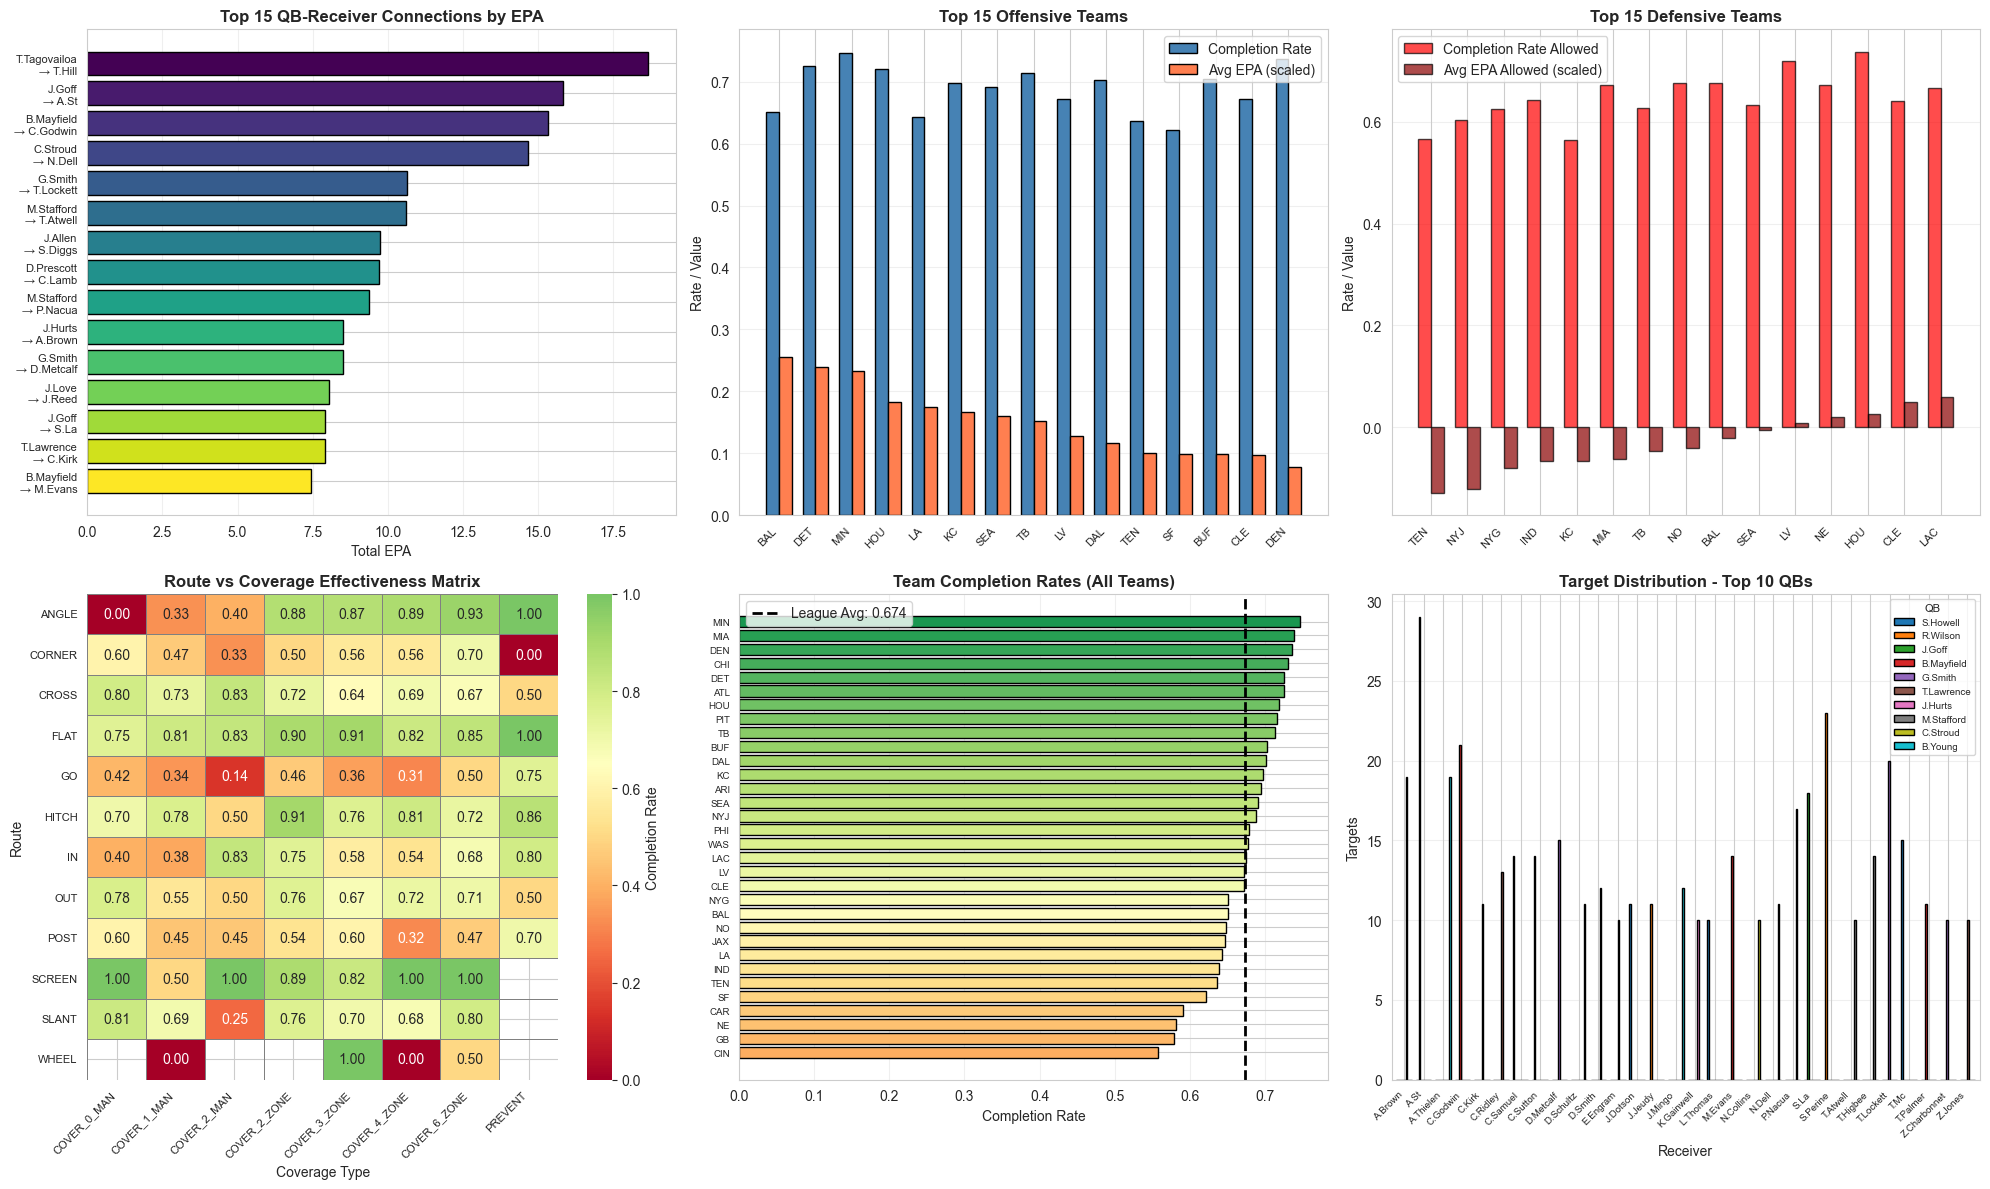


Saved network_analysis.png


In [11]:
# Create network analysis visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Top QB-Receiver Connections
ax1 = plt.subplot(2, 3, 1)
top_connections = qb_receiver_stats.head(15).copy()
top_connections['connection'] = top_connections['passer'] + '\n→ ' + top_connections['receiver']
colors = plt.cm.viridis(np.linspace(0, 1, len(top_connections)))
bars = ax1.barh(range(len(top_connections)), top_connections['total_epa'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(top_connections)))
ax1.set_yticklabels(top_connections['connection'], fontsize=8)
ax1.set_xlabel('Total EPA', fontsize=10)
ax1.set_title('Top 15 QB-Receiver Connections by EPA', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Team Offensive Efficiency
ax2 = plt.subplot(2, 3, 2)
top_offense = team_offense_stats.head(15)
x = np.arange(len(top_offense))
width = 0.35
ax2.bar(x - width/2, top_offense['completion_rate'], width, label='Completion Rate', 
        color='steelblue', edgecolor='black')
ax2.bar(x + width/2, top_offense['avg_epa']/2, width, label='Avg EPA (scaled)', 
        color='coral', edgecolor='black')
ax2.set_ylabel('Rate / Value', fontsize=10)
ax2.set_title('Top 15 Offensive Teams', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(top_offense.index, rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Team Defensive Efficiency
ax3 = plt.subplot(2, 3, 3)
top_defense = team_defense_stats.head(15)
x = np.arange(len(top_defense))
ax3.bar(x - width/2, top_defense['completion_rate_allowed'], width, 
        label='Completion Rate Allowed', color='red', alpha=0.7, edgecolor='black')
ax3.bar(x + width/2, top_defense['avg_epa_allowed']/2, width, 
        label='Avg EPA Allowed (scaled)', color='darkred', alpha=0.7, edgecolor='black')
ax3.set_ylabel('Rate / Value', fontsize=10)
ax3.set_title('Top 15 Defensive Teams', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(top_defense.index, rotation=45, ha='right', fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Route Effectiveness Heatmap
ax4 = plt.subplot(2, 3, 4)
route_coverage_clean = route_coverage_matrix.iloc[:12, :8]  # Remove Unknown and limit size
sns.heatmap(route_coverage_clean, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0.65, ax=ax4, cbar_kws={'label': 'Completion Rate'}, 
            linewidths=0.5, linecolor='gray')
ax4.set_xlabel('Coverage Type', fontsize=10)
ax4.set_ylabel('Route', fontsize=10)
ax4.set_title('Route vs Coverage Effectiveness Matrix', fontsize=12, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=8)

# 5. Completion Rate Distribution by Team
ax5 = plt.subplot(2, 3, 5)
team_completion_dist = model_data.groupby('possession_team')['is_completion'].mean().sort_values()
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(team_completion_dist)))
ax5.barh(range(len(team_completion_dist)), team_completion_dist.values, 
         color=colors_gradient, edgecolor='black')
ax5.set_yticks(range(len(team_completion_dist)))
ax5.set_yticklabels(team_completion_dist.index, fontsize=7)
ax5.set_xlabel('Completion Rate', fontsize=10)
ax5.set_title('Team Completion Rates (All Teams)', fontsize=12, fontweight='bold')
ax5.axvline(x=team_completion_dist.mean(), color='black', linestyle='--', 
            linewidth=2, label=f'League Avg: {team_completion_dist.mean():.3f}')
ax5.legend()
ax5.grid(axis='x', alpha=0.3)

# 6. Target Distribution for Top QBs
ax6 = plt.subplot(2, 3, 6)
top_qbs = qb_receiver_stats.groupby('passer')['targets'].sum().nlargest(10)
qb_target_dist = qb_receiver_stats[qb_receiver_stats['passer'].isin(top_qbs.index)]
qb_pivot = qb_target_dist.pivot_table(values='targets', index='passer', 
                                       columns='receiver', fill_value=0)
qb_pivot_top = qb_pivot.loc[top_qbs.index]
# Get top 5 receivers for each QB
qb_pivot_top_5 = qb_pivot_top.apply(lambda x: x.nlargest(5), axis=1).fillna(0)
qb_pivot_top_5.T.plot(kind='bar', ax=ax6, width=0.8, edgecolor='black')
ax6.set_xlabel('Receiver', fontsize=10)
ax6.set_ylabel('Targets', fontsize=10)
ax6.set_title('Target Distribution - Top 10 QBs', fontsize=12, fontweight='bold')
ax6.legend(title='QB', fontsize=7, title_fontsize=8, loc='upper right')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Two-Minute Drill/network_analysis_two_minute.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved network_analysis.png")

In [12]:
print("="*60)
print("PREPARING INTERACTIVE DASHBOARD DATA (TWO-MINUTE DRILL ONLY)")
print("="*60)

# Filter for two-minute drill plays only
model_data_2min = model_data[model_data['is_two_minute_drill'] == True].copy()
print(f"\nFiltered to {len(model_data_2min)} two-minute drill plays (from {len(model_data)} total plays)")

# Prepare comprehensive data for dashboard
dashboard_data = {}

# 1. Overall Statistics (Two-Minute Drill Only)
dashboard_data['overall_stats'] = {
    'total_plays': len(model_data_2min),
    'completion_rate': model_data_2min['is_completion'].mean(),
    'avg_epa': model_data_2min['expected_points_added'].mean(),
    'avg_pass_length': model_data_2min['pass_length'].mean(),
    'total_weeks': model_data_2min['week'].nunique(),
    'total_games': model_data_2min['game_id'].nunique(),
    'avg_defender_proximity': model_data_2min['closest_defender_dist'].mean(),
    'avg_receiver_speed': model_data_2min['receiver_speed'].mean()
}

# 2. Situation-based Statistics (Quarter breakdown for two-minute drill)
dashboard_data['situation_stats'] = model_data_2min.groupby('quarter').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'pass_length': 'mean',
    'play_id': 'count'
}).round(3)

# Add red zone stats (within two-minute drill)
redzone_in = model_data_2min[model_data_2min['is_redzone']].agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
})
redzone_out = model_data_2min[~model_data_2min['is_redzone']].agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
})

dashboard_data['redzone_stats'] = pd.DataFrame({
    'in_redzone': redzone_in,
    'outside_redzone': redzone_out
}).T

# 3. Coverage Type Analysis (Two-Minute Drill)
dashboard_data['coverage_stats'] = model_data_2min.groupby('team_coverage_type').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3).sort_values('is_completion', ascending=False)

# 4. Route Analysis (Two-Minute Drill)
dashboard_data['route_stats'] = model_data_2min.groupby('route_of_targeted_receiver').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'pass_length': 'mean',
    'play_id': 'count'
}).round(3).sort_values('is_completion', ascending=False)

# 5. Formation Analysis (Two-Minute Drill)
dashboard_data['formation_stats'] = model_data_2min.groupby('offense_formation').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3).sort_values('expected_points_added', ascending=False)

# 6. Weekly Trends (Two-Minute Drill)
dashboard_data['weekly_trends'] = model_data_2min.groupby('week').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'pass_length': 'mean',
    'receiver_speed': 'mean',
    'closest_defender_dist': 'mean',
    'play_id': 'count'
}).round(3)

# 7. Team Rankings (Offense - Two-Minute Drill)
dashboard_data['team_offense_rankings'] = model_data_2min.groupby('possession_team').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'yards_gained': 'mean',
    'play_id': 'count'
}).round(3).sort_values('expected_points_added', ascending=False).head(10)

# 8. Team Rankings (Defense - Two-Minute Drill)
dashboard_data['team_defense_rankings'] = model_data_2min.groupby('defensive_team').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'yards_gained': 'mean',
    'play_id': 'count'
}).round(3).sort_values('expected_points_added', ascending=True).head(10)

# 9. Defender Proximity Analysis (Two-Minute Drill)
model_data_2min['defender_proximity_bin'] = pd.cut(
    model_data_2min['closest_defender_dist'],
    bins=[0, 2, 5, 10, 15, 100],
    labels=['<2 yds', '2-5 yds', '5-10 yds', '10-15 yds', '15+ yds']
)

dashboard_data['defender_proximity_stats'] = model_data_2min.groupby('defender_proximity_bin', observed=True).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# 10. Speed Analysis (Two-Minute Drill)
model_data_2min['speed_category'] = pd.cut(
    model_data_2min['receiver_speed'],
    bins=[0, 2, 4, 6, 8, 15],
    labels=['Very Slow (0-2)', 'Slow (2-4)', 'Medium (4-6)', 'Fast (6-8)', 'Very Fast (8+)']
)

dashboard_data['speed_stats'] = model_data_2min.groupby('speed_category', observed=True).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# 11. Down and Distance Analysis (Two-Minute Drill)
dashboard_data['down_distance_stats'] = model_data_2min.groupby(['down', 'yards_to_go']).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# 12. Time Remaining Analysis (Two-Minute Drill)
def parse_game_clock(clock_str):
    try:
        parts = str(clock_str).split(':')
        return int(parts[0]) + int(parts[1])/60
    except:
        return np.nan

model_data_2min['minutes_remaining'] = model_data_2min['game_clock'].apply(parse_game_clock)
model_data_2min['time_category'] = pd.cut(
    model_data_2min['minutes_remaining'],
    bins=[0, 0.5, 1.0, 1.5, 2.0],
    labels=['0-30 sec', '30-60 sec', '1-1.5 min', '1.5-2 min']
)

dashboard_data['time_pressure_stats'] = model_data_2min.groupby('time_category', observed=True).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# Save dashboard data
print("\nCreating structured dashboard tables...")

# Table 1: Overall Metrics
overall_df = pd.DataFrame([dashboard_data['overall_stats']])
overall_df.to_csv('Two-Minute Drill/dashboard_overall_stats_2min.csv', index=False)
print("✓ Saved dashboard_overall_stats_2min.csv")

# Table 2: Coverage Performance
dashboard_data['coverage_stats'].to_csv('Two-Minute Drill/dashboard_coverage_stats_2min.csv')
print("✓ Saved dashboard_coverage_stats_2min.csv")

# Table 3: Route Performance
dashboard_data['route_stats'].to_csv('Two-Minute Drill/dashboard_route_stats_2min.csv')
print("✓ Saved dashboard_route_stats_2min.csv")

# Table 4: Weekly Trends
dashboard_data['weekly_trends'].to_csv('Two-Minute Drill/dashboard_weekly_trends_2min.csv')
print("✓ Saved dashboard_weekly_trends_2min.csv")

# Table 5: Team Offense Rankings
dashboard_data['team_offense_rankings'].to_csv('Two-Minute Drill/dashboard_team_offense_2min.csv')
print("✓ Saved dashboard_team_offense_2min.csv")

# Table 6: Team Defense Rankings
dashboard_data['team_defense_rankings'].to_csv('Two-Minute Drill/dashboard_team_defense_2min.csv')
print("✓ Saved dashboard_team_defense_2min.csv")

# Table 7: Defender Proximity
dashboard_data['defender_proximity_stats'].to_csv('Two-Minute Drill/dashboard_defender_proximity_2min.csv')
print("✓ Saved dashboard_defender_proximity_2min.csv")

# Table 8: Speed Analysis
dashboard_data['speed_stats'].to_csv('Two-Minute Drill/dashboard_speed_stats_2min.csv')
print("✓ Saved dashboard_speed_stats_2min.csv")

# Table 9: Time Pressure
dashboard_data['time_pressure_stats'].to_csv('Two-Minute Drill/dashboard_time_pressure_2min.csv')
print("✓ Saved dashboard_time_pressure_2min.csv")

# Table 10: Red Zone Stats
dashboard_data['redzone_stats'].to_csv('Two-Minute Drill/dashboard_redzone_stats_2min.csv')
print("✓ Saved dashboard_redzone_stats_2min.csv")

# Table 11: Formation Stats
dashboard_data['formation_stats'].to_csv('Two-Minute Drill/dashboard_formation_stats_2min.csv')
print("✓ Saved dashboard_formation_stats_2min.csv")

# Display summary
print("\n" + "="*60)
print("DASHBOARD DATA SUMMARY (TWO-MINUTE DRILL ONLY)")
print("="*60)
print(f"\nOverall Statistics:")
for key, value in dashboard_data['overall_stats'].items():
    if isinstance(value, float):
        print(f"  - {key}: {value:.3f}")
    else:
        print(f"  - {key}: {value}")

print(f"\nTop 5 Coverage Types by Completion Rate (Two-Minute Drill):")
coverage_comp = dashboard_data['coverage_stats'].sort_values('is_completion', ascending=False)
for idx, row in coverage_comp.head().iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} ({int(row['play_id'])} plays)")

print(f"\nTop 5 Routes by Completion Rate (Two-Minute Drill):")
route_comp = dashboard_data['route_stats'].sort_values('is_completion', ascending=False)
for idx, row in route_comp.head().iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} ({int(row['play_id'])} plays)")

print(f"\nTop 5 Offensive Teams by EPA (Two-Minute Drill):")
team_off_epa = dashboard_data['team_offense_rankings'].sort_values('expected_points_added', ascending=False)
for idx, row in team_off_epa.head().iterrows():
    print(f"  - {idx}: {row['expected_points_added']:.3f} EPA, {row['is_completion']:.3f} comp rate ({int(row['play_id'])} plays)")

print(f"\nTop 5 Defensive Teams by EPA Allowed (Two-Minute Drill):")
team_def_epa = dashboard_data['team_defense_rankings'].sort_values('expected_points_added', ascending=True)
for idx, row in team_def_epa.head().iterrows():
    print(f"  - {idx}: {row['expected_points_added']:.3f} EPA allowed, {row['is_completion']:.3f} comp rate allowed ({int(row['play_id'])} plays)")

print(f"\nDefender Proximity Impact (Two-Minute Drill):")
defender_prox_comp = dashboard_data['defender_proximity_stats']
for idx, row in defender_prox_comp.iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} completion rate ({int(row['play_id'])} plays)")

print(f"\nTime Pressure Impact (Two-Minute Drill):")
time_pressure_comp = dashboard_data['time_pressure_stats']
for idx, row in time_pressure_comp.iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} completion rate ({int(row['play_id'])} plays)")

print(f"\nQuarter Breakdown (Two-Minute Drill):")
quarter_stats = dashboard_data['situation_stats']
for idx, row in quarter_stats.iterrows():
    print(f"  - Quarter {int(idx)}: {row['is_completion']:.3f} comp rate, {row['expected_points_added']:.3f} EPA ({int(row['play_id'])} plays)")

print(f"\nRed Zone vs Outside Red Zone (Two-Minute Drill):")
for idx, row in dashboard_data['redzone_stats'].iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} comp rate, {row['expected_points_added']:.3f} EPA ({int(row['play_id'])} plays)")

print("\n" + "="*60)
print("All dashboard data files created successfully!")
print("="*60)

PREPARING INTERACTIVE DASHBOARD DATA (TWO-MINUTE DRILL ONLY)

Filtered to 2134 two-minute drill plays (from 2134 total plays)

Creating structured dashboard tables...
✓ Saved dashboard_overall_stats_2min.csv
✓ Saved dashboard_coverage_stats_2min.csv
✓ Saved dashboard_route_stats_2min.csv
✓ Saved dashboard_weekly_trends_2min.csv
✓ Saved dashboard_team_offense_2min.csv
✓ Saved dashboard_team_defense_2min.csv
✓ Saved dashboard_defender_proximity_2min.csv
✓ Saved dashboard_speed_stats_2min.csv
✓ Saved dashboard_time_pressure_2min.csv
✓ Saved dashboard_redzone_stats_2min.csv
✓ Saved dashboard_formation_stats_2min.csv

DASHBOARD DATA SUMMARY (TWO-MINUTE DRILL ONLY)

Overall Statistics:
  - total_plays: 2134
  - completion_rate: 0.677
  - avg_epa: 0.120
  - avg_pass_length: 9.552
  - total_weeks: 18
  - total_games: 272
  - avg_defender_proximity: 4.502
  - avg_receiver_speed: 5.525

Top 5 Coverage Types by Completion Rate (Two-Minute Drill):
  - COVER_2_ZONE: 0.772 (316 plays)
  - COVER_6_ZO

✓ Saved comprehensive_dashboard_2min_drill.png


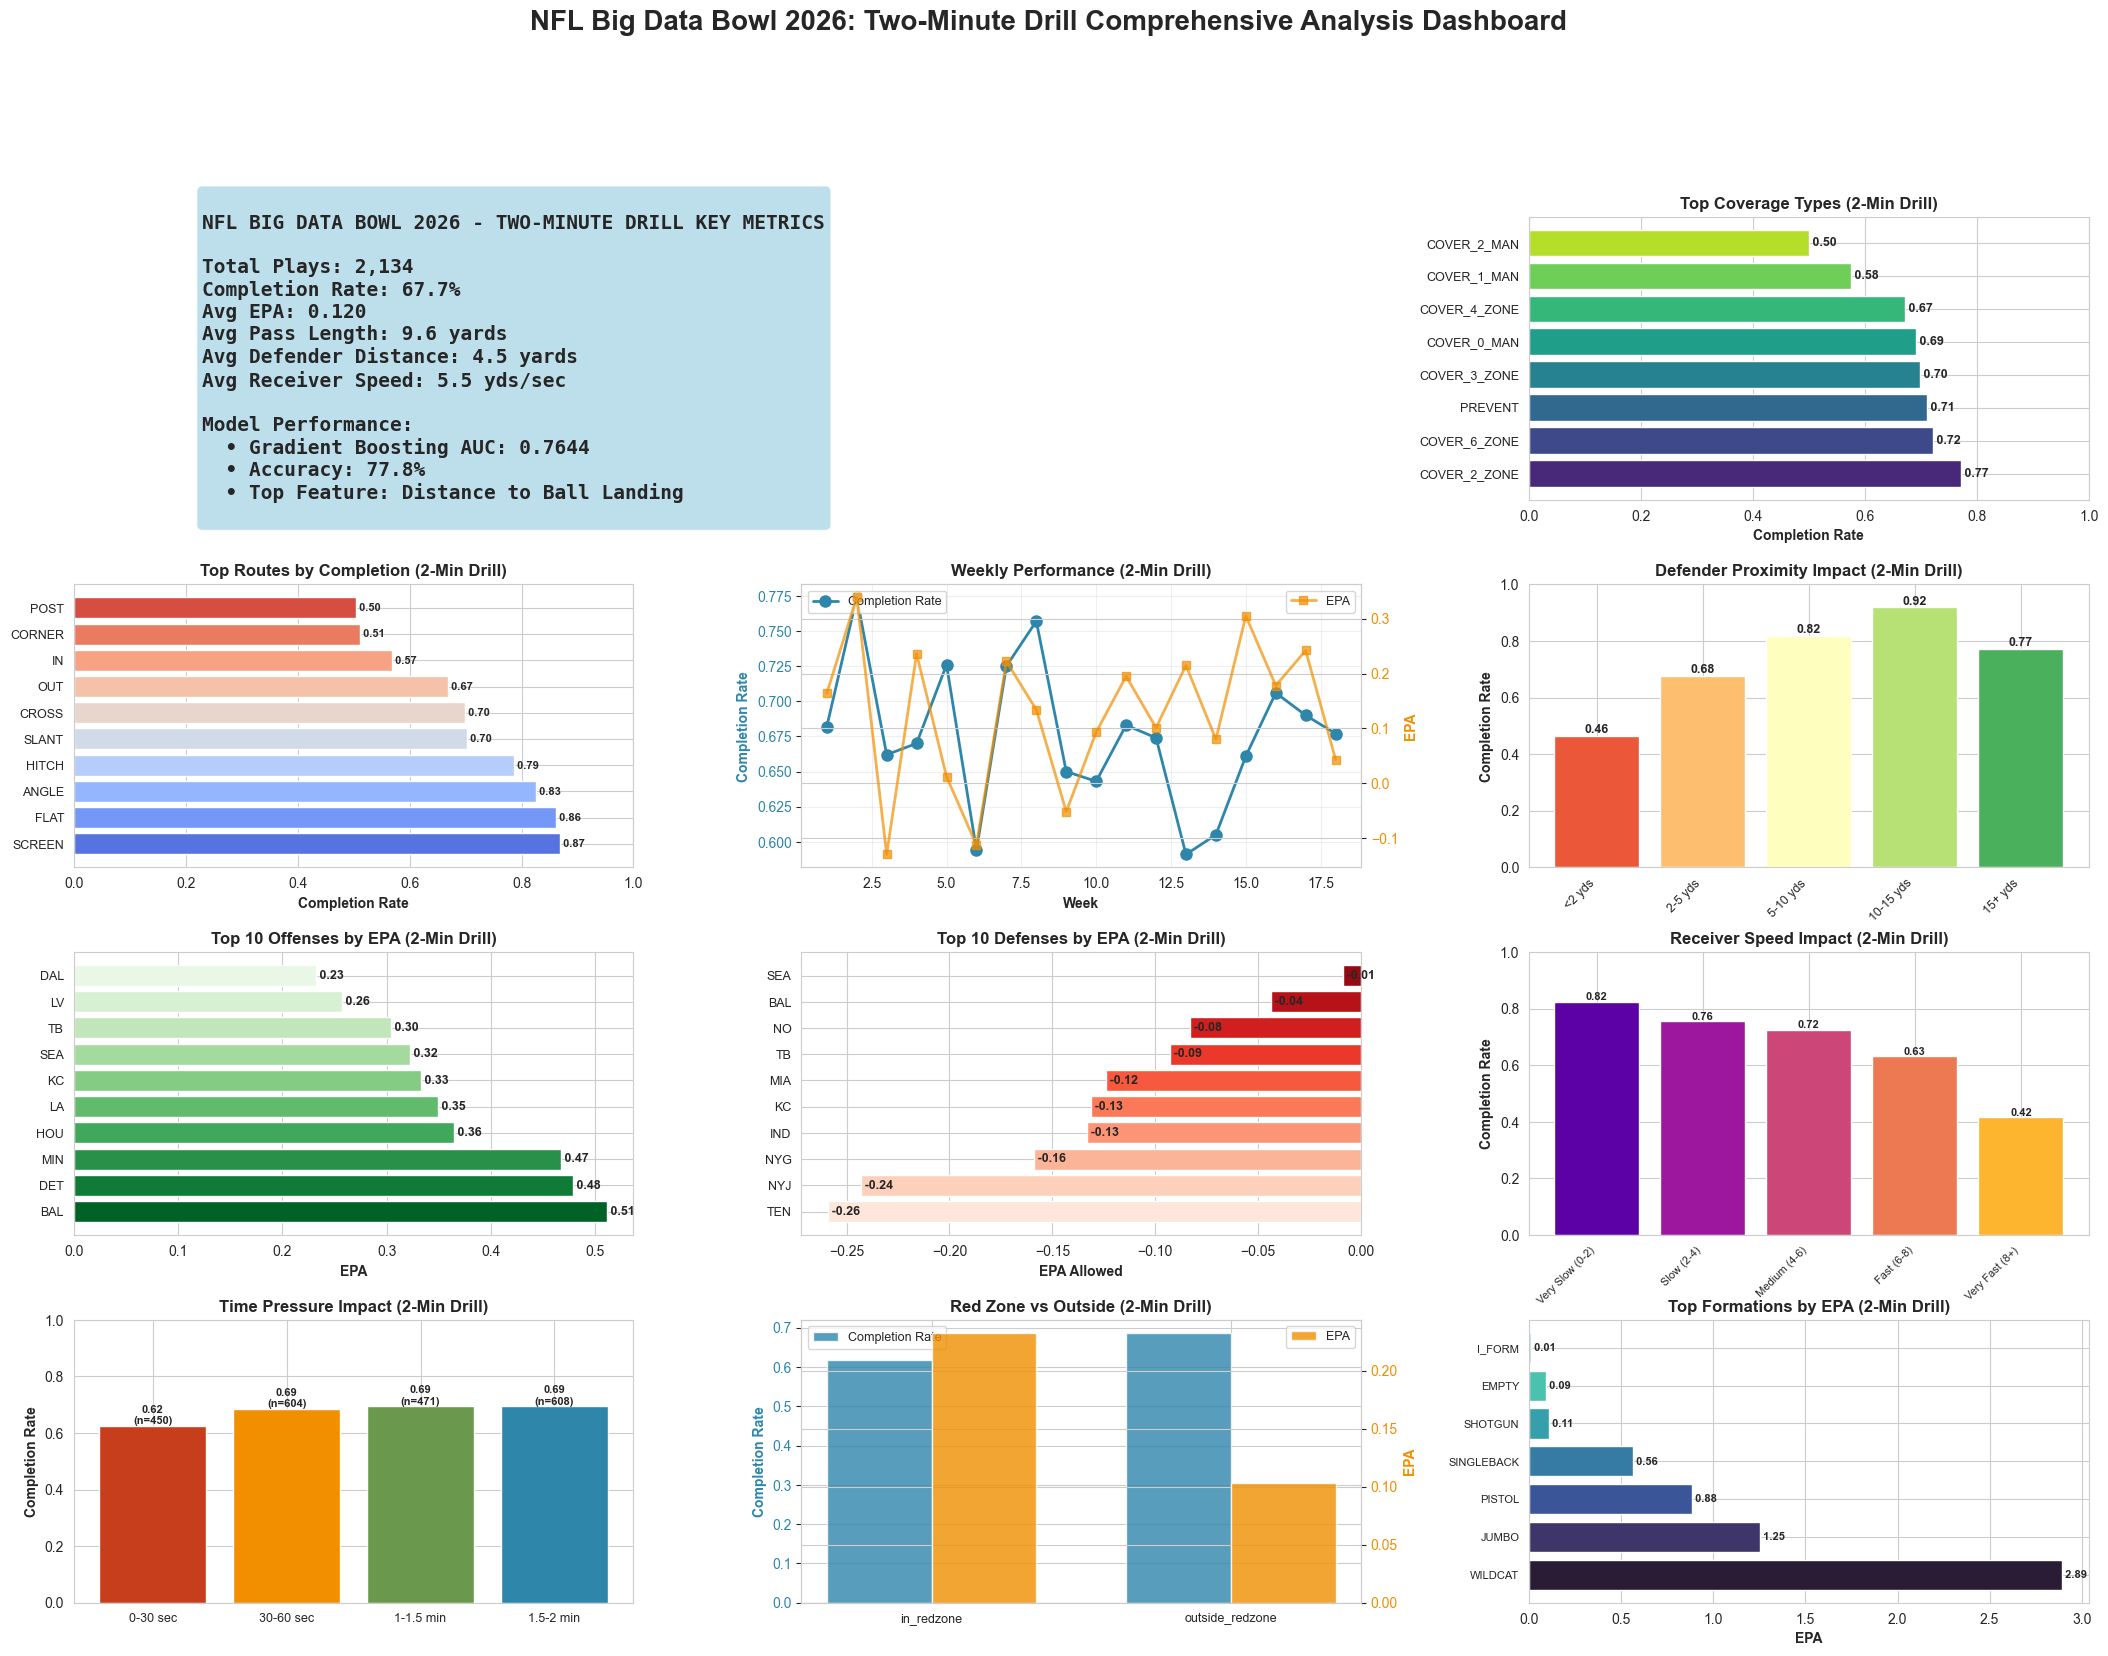


COMPREHENSIVE DASHBOARD CREATED SUCCESSFULLY!


In [15]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(26, 18))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Key Metrics Summary
ax1 = fig.add_subplot(gs[0, :2])
ax1.axis('off')
metrics_text = f"""
NFL BIG DATA BOWL 2026 - TWO-MINUTE DRILL KEY METRICS

Total Plays: {dashboard_data['overall_stats']['total_plays']:,}
Completion Rate: {dashboard_data['overall_stats']['completion_rate']:.1%}
Avg EPA: {dashboard_data['overall_stats']['avg_epa']:.3f}
Avg Pass Length: {dashboard_data['overall_stats']['avg_pass_length']:.1f} yards
Avg Defender Distance: {dashboard_data['overall_stats']['avg_defender_proximity']:.1f} yards
Avg Receiver Speed: {dashboard_data['overall_stats']['avg_receiver_speed']:.1f} yds/sec

Model Performance:
  • Gradient Boosting AUC: {gb_auc:.4f}
  • Accuracy: {(gb_pred == y_test).mean():.1%}
  • Top Feature: Distance to Ball Landing
"""
ax1.text(0.1, 0.5, metrics_text, fontsize=14, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
         family='monospace', fontweight='bold')

# 2. Completion Rate by Coverage
ax2 = fig.add_subplot(gs[0, 2])
coverage_top = dashboard_data['coverage_stats'].head(8)
bars = ax2.barh(range(len(coverage_top)), coverage_top['is_completion'], 
                color=sns.color_palette("viridis", len(coverage_top)))
ax2.set_yticks(range(len(coverage_top)))
ax2.set_yticklabels(coverage_top.index, fontsize=9)
ax2.set_xlabel('Completion Rate', fontweight='bold')
ax2.set_title('Top Coverage Types (2-Min Drill)', fontweight='bold', fontsize=12)
ax2.set_xlim([0, 1])
for i, (bar, val) in enumerate(zip(bars, coverage_top['is_completion'])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=9, fontweight='bold')

# 3. Route Effectiveness
ax3 = fig.add_subplot(gs[1, 0])
route_top = dashboard_data['route_stats'].head(10)
bars = ax3.barh(range(len(route_top)), route_top['is_completion'],
                color=sns.color_palette("coolwarm", len(route_top)))
ax3.set_yticks(range(len(route_top)))
ax3.set_yticklabels(route_top.index, fontsize=9)
ax3.set_xlabel('Completion Rate', fontweight='bold')
ax3.set_title('Top Routes by Completion (2-Min Drill)', fontweight='bold', fontsize=12)
ax3.set_xlim([0, 1])
for i, (bar, val) in enumerate(zip(bars, route_top['is_completion'])):
    ax3.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=8, fontweight='bold')

# 4. Weekly Trends
ax4 = fig.add_subplot(gs[1, 1])
weekly = dashboard_data['weekly_trends']
ax4.plot(weekly.index, weekly['is_completion'], marker='o', linewidth=2, 
         markersize=8, color='#2E86AB', label='Completion Rate')
ax4_twin = ax4.twinx()
ax4_twin.plot(weekly.index, weekly['expected_points_added'], marker='s', 
              linewidth=2, markersize=6, color='#F18F01', label='EPA', alpha=0.7)
ax4.set_xlabel('Week', fontweight='bold')
ax4.set_ylabel('Completion Rate', fontweight='bold', color='#2E86AB')
ax4_twin.set_ylabel('EPA', fontweight='bold', color='#F18F01')
ax4.set_title('Weekly Performance (2-Min Drill)', fontweight='bold', fontsize=12)
ax4.tick_params(axis='y', labelcolor='#2E86AB')
ax4_twin.tick_params(axis='y', labelcolor='#F18F01')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)

# 5. Defender Proximity Impact
ax5 = fig.add_subplot(gs[1, 2])
defender_prox = dashboard_data['defender_proximity_stats']
bars = ax5.bar(range(len(defender_prox)), defender_prox['is_completion'],
               color=sns.color_palette("RdYlGn", len(defender_prox)))
ax5.set_xticks(range(len(defender_prox)))
ax5.set_xticklabels(defender_prox.index, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel('Completion Rate', fontweight='bold')
ax5.set_title('Defender Proximity Impact (2-Min Drill)', fontweight='bold', fontsize=12)
ax5.set_ylim([0, 1])
for bar, val in zip(bars, defender_prox['is_completion']):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Team Offense Rankings
ax6 = fig.add_subplot(gs[2, 0])
team_off = dashboard_data['team_offense_rankings'].head(10)
bars = ax6.barh(range(len(team_off)), team_off['expected_points_added'],
                color=sns.color_palette("Greens_r", len(team_off)))
ax6.set_yticks(range(len(team_off)))
ax6.set_yticklabels(team_off.index, fontsize=9)
ax6.set_xlabel('EPA', fontweight='bold')
ax6.set_title('Top 10 Offenses by EPA (2-Min Drill)', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, team_off['expected_points_added'])):
    ax6.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=9, fontweight='bold')

# 7. Team Defense Rankings
ax7 = fig.add_subplot(gs[2, 1])
team_def = dashboard_data['team_defense_rankings'].head(10)
bars = ax7.barh(range(len(team_def)), team_def['expected_points_added'],
                color=sns.color_palette("Reds", len(team_def)))
ax7.set_yticks(range(len(team_def)))
ax7.set_yticklabels(team_def.index, fontsize=9)
ax7.set_xlabel('EPA Allowed', fontweight='bold')
ax7.set_title('Top 10 Defenses by EPA (2-Min Drill)', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, team_def['expected_points_added'])):
    ax7.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=9, fontweight='bold')

# 8. Speed Analysis
ax8 = fig.add_subplot(gs[2, 2])
speed = dashboard_data['speed_stats']
bars = ax8.bar(range(len(speed)), speed['is_completion'],
               color=sns.color_palette("plasma", len(speed)))
ax8.set_xticks(range(len(speed)))
ax8.set_xticklabels(speed.index, rotation=45, ha='right', fontsize=8)
ax8.set_ylabel('Completion Rate', fontweight='bold')
ax8.set_title('Receiver Speed Impact (2-Min Drill)', fontweight='bold', fontsize=12)
ax8.set_ylim([0, 1])
for bar, val in zip(bars, speed['is_completion']):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 9. Time Pressure Analysis
ax9 = fig.add_subplot(gs[3, 0])
time_pressure = dashboard_data['time_pressure_stats']
bars = ax9.bar(range(len(time_pressure)), time_pressure['is_completion'],
               color=['#C73E1D', '#F18F01', '#6A994E', '#2E86AB'])
ax9.set_xticks(range(len(time_pressure)))
ax9.set_xticklabels(time_pressure.index, rotation=0, fontsize=9)
ax9.set_ylabel('Completion Rate', fontweight='bold')
ax9.set_title('Time Pressure Impact (2-Min Drill)', fontweight='bold', fontsize=12)
ax9.set_ylim([0, 1])
for bar, val, count in zip(bars, time_pressure['is_completion'], time_pressure['play_id']):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}\n(n={int(count)})', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 10. Red Zone Performance
ax10 = fig.add_subplot(gs[3, 1])
redzone = dashboard_data['redzone_stats']
x = np.arange(len(redzone))
width = 0.35
bars1 = ax10.bar(x - width/2, redzone['is_completion'], width, 
                 label='Completion Rate', color='#2E86AB', alpha=0.8)
ax10_twin = ax10.twinx()
bars2 = ax10_twin.bar(x + width/2, redzone['expected_points_added'], width,
                      label='EPA', color='#F18F01', alpha=0.8)
ax10.set_xticks(x)
ax10.set_xticklabels(redzone.index, rotation=0, fontsize=9)
ax10.set_ylabel('Completion Rate', fontweight='bold', color='#2E86AB')
ax10_twin.set_ylabel('EPA', fontweight='bold', color='#F18F01')
ax10.set_title('Red Zone vs Outside (2-Min Drill)', fontweight='bold', fontsize=12)
ax10.tick_params(axis='y', labelcolor='#2E86AB')
ax10_twin.tick_params(axis='y', labelcolor='#F18F01')
ax10.legend(loc='upper left', fontsize=9)
ax10_twin.legend(loc='upper right', fontsize=9)

# 11. Formation Effectiveness
ax11 = fig.add_subplot(gs[3, 2])
formation = dashboard_data['formation_stats'].head(8)
bars = ax11.barh(range(len(formation)), formation['expected_points_added'],
                 color=sns.color_palette("mako", len(formation)))
ax11.set_yticks(range(len(formation)))
ax11.set_yticklabels(formation.index, fontsize=8)
ax11.set_xlabel('EPA', fontweight='bold')
ax11.set_title('Top Formations by EPA (2-Min Drill)', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, formation['expected_points_added'])):
    ax11.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
              va='center', fontsize=8, fontweight='bold')

plt.suptitle('NFL Big Data Bowl 2026: Two-Minute Drill Comprehensive Analysis Dashboard', 
             fontsize=20, fontweight='bold', y=0.995)

plt.savefig('Two-Minute Drill/comprehensive_dashboard_2min_drill.png', dpi=300, bbox_inches='tight')
print("✓ Saved comprehensive_dashboard_2min_drill.png")
plt.show()

print("\n" + "="*60)
print("COMPREHENSIVE DASHBOARD CREATED SUCCESSFULLY!")
print("="*60)